# Análisis estadístico avanzado y aprendizaje automático aplicado a la predicción de la demanda de bicicletas compartidas

# Maicol Patiño Sierra

# Conjunto de datos

Se utilizará el conjunto de datos abierto:

**Seoul Bike Sharing Demand**

Repositorio oficial:

https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

El conjunto de datos contiene aproximadamente 8.700 observaciones correspondientes a una hora de funcionamiento del sistema de bicicletas compartidas.

Entre las variables disponibles se encuentran:

- Fecha.
- Hora.
- Temperatura.
- Humedad.
- Velocidad del viento.
- Visibilidad.
- Radiación solar.
- Lluvia.
- Nieve.
- Estación del año.
- Festivo.
- Día de funcionamiento.
- Número de bicicletas alquiladas.

La variable objetivo principal será:

**Rented Bike Count**

## 1. Comprensión del problema

**Contexto del problema:**
El sistema público de bicicletas compartidas de la ciudad de Seúl es una alternativa clave para la movilidad urbana sostenible. Sin embargo, la demanda de este servicio no es constante y se encuentra condicionada por múltiples factores externos. Las variaciones meteorológicas (como la temperatura, la humedad, la radiación solar y las precipitaciones) junto con las dinámicas temporales (como la hora del día, los días festivos y la estación del año) influyen de manera directa en la decisión de los usuarios de alquilar una bicicleta. 

**Objetivo del estudio:**
El objetivo principal de este proyecto consiste en predecir la demanda de bicicletas compartidas **(Rented Bike Count)** con base en variables meteorológicas y de tiempo a partir de diferentes técnicas estadísticas.

**Unidad de análisis:**
La unidad de análisis de este estudio es la cantidad de bicicletas rentadas por hora.

**Posibles aplicaciones prácticas:**
La correcta modelización e interpretación de estos datos permite generar valor mediante aplicaciones como:

*   **Optimización de inventario y logística:** Anticipar picos de demanda para redistribuir las bicicletas entre estaciones, garantizando disponibilidad y evitando el colapso del sistema, además de evitar la subutilización de las mismas. 
*   **Mantenimiento eficiente:** Identificar periodos con una baja demanda y las condiciones que lo causan para programar el mantenimiento preventivo de la bicicletas sin afectar la disponibilidad.
*   **Planificación urbana:** Aportar información basada en datos a las autoridades locales sobre los patrones de movilidad, facilitando la toma de decisiones sobre la ampliación de la infraestructura para las bicicletas en horarios o temporadas críticas.
*   **Iniciativas de salud pública:** Identificar patrones de uso en los habitantes para proponer fechas o temporadas especiales que fomenten el uso de la bicicleta en temporadas con poco uso, para mejorar la salud de la población.

## 2. Comprensión del conjunto de datos

Análisis inicial del conjunto de datos:

- dimensiones;
- tipos de variables;
- descripción de cada atributo;
- variable objetivo.

---

In [146]:
#Importacion de librerias
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.cluster import KMeans
import skfuzzy as fuzz

In [147]:
# fetch dataset importación del dataset desde el repositorio de UCI
seoul_bike_sharing_demand = fetch_ucirepo(id=560) 
  
# data (as pandas dataframes) en el origen están separadas las variables predictoras y la variable objetivo
X = seoul_bike_sharing_demand.data.features 
y = seoul_bike_sharing_demand.data.targets 

# Combinar en un solo DataFrame
df = pd.concat([X, y], axis=1)


In [148]:
#Análisis inicial del conjunto de datos
# Dimensiones del conjunto de datos
print("\nDimensiones del conjunto de datos: (Filas, Columnas)", df.shape)

# Tipos de variables
print("\nTipos de variables:\n")
print(df.info())

#descripción de cada atributo
print("\nDescripción de cada atributo: \n", df.describe(include="all"))


Dimensiones del conjunto de datos: (Filas, Columnas) (8760, 14)

Tipos de variables:

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   str    
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   str    
 12  Holiday                8760 non-null   str    
 13  Functioning Day        8760 non-

**Posibles datos inconsistentes** En la naturaleza no se presenta la humedad relativa de 0, lo que en terminos generales se puede identificar como un dato inconsistente que valdría la pena corregir en pasos posteriores.

In [149]:
# Vista previa del dataset, visualización datos iniciales
print("Primeros 5 registros del dataset:\n", df.head(5))

Primeros 5 registros del dataset:
         Date  Rented Bike Count  Hour  Temperature  Humidity  Wind speed  Visibility  Dew point temperature  Solar Radiation  Rainfall  Snowfall Seasons     Holiday Functioning Day
0  1/12/2017                254     0         -5.2        37         2.2        2000                  -17.6              0.0       0.0       0.0  Winter  No Holiday             Yes
1  1/12/2017                204     1         -5.5        38         0.8        2000                  -17.6              0.0       0.0       0.0  Winter  No Holiday             Yes
2  1/12/2017                173     2         -6.0        39         1.0        2000                  -17.7              0.0       0.0       0.0  Winter  No Holiday             Yes
3  1/12/2017                107     3         -6.2        40         0.9        2000                  -17.6              0.0       0.0       0.0  Winter  No Holiday             Yes
4  1/12/2017                 78     4         -6.0        36

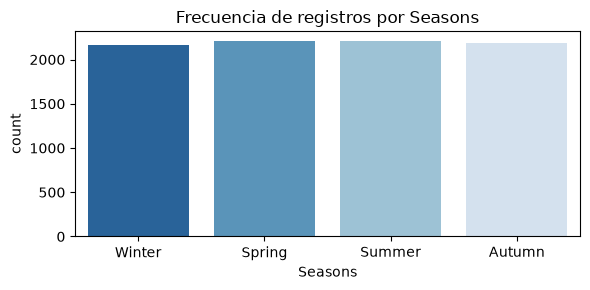

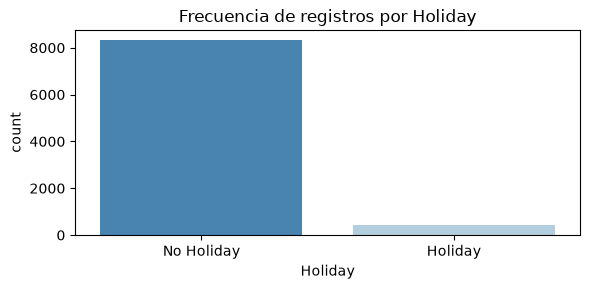

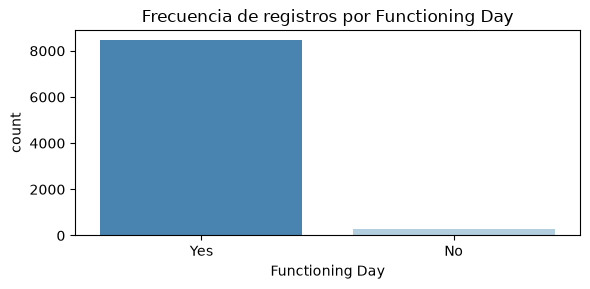

In [150]:
# Análisis de las variables categóricas
# Creamos una lista de variable categóricas
cat_cols = ['Seasons', 'Holiday', 'Functioning Day']

# Ciclo para generar gráficos de frecuencias por cada variable categórica
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(6, 3))

    sns.countplot(
        data=df, x=col, hue=col, ax=ax, palette='Blues_r', legend=False
    )
    ax.set_title(f'Frecuencia de registros por {col}')

    plt.tight_layout()
    plt.show()

In [151]:
# Análisis numérico de frecuencias en variables categóricas

for col in cat_cols:
    print(f"--- Frecuencias para: {col} ---")
    print(df[col].value_counts())
    print()

--- Frecuencias para: Seasons ---
Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

--- Frecuencias para: Holiday ---
Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

--- Frecuencias para: Functioning Day ---
Functioning Day
Yes    8465
No      295
Name: count, dtype: int64



In [152]:
# Verificación de la relación entre el día de funcionamiento y el conteo de bicicletas alquiladas
print(df.groupby("Functioning Day")["Rented Bike Count"].mean())

Functioning Day
No       0.000000
Yes    729.156999
Name: Rented Bike Count, dtype: float64


**Análisis de la Estructura y Estadísticas Descriptivas**

* **Estructura y Completitud:** El dataset contiene **8,760 registros y 14 columnas**, equivalentes a 365 días seguidos en mediciones de 24 horas.
* **Comportamiento de la Variable Objetivo (`Rented Bike Count`):**
  * La media (**704.6**) supera a la mediana (**504.5**), confirmando un sesgo a la derecha (asimetría positiva).
  * Presenta alta dispersión, oscilando entre **0 y 3,556 alquileres/hora** con una desviación estándar de **644.99**.
* **Patrones Climáticos Identificados:**
  * **Eventos esporádicos:** `Rainfall` y `Snowfall` tienen sus percentiles 25%, 50% y 75% en 0, lo que significa que la lluvia y la nieve son eventos que no pasan de manera muy frecuente, esto se puede relacionar con las temporadas.
  * **Amplitud térmica:** La temperatura varía desde **-17.8°C** en invierno hasta **39.4°C** en verano, lo que nos demuestra unas temporadas muy marcadas y diferenciadas en terminos de temperatura que podremos analizar a continuación.
  * **Visibilidad:** `Visibility` en promedio la visibilidad es buena teniendo de valores promedio de 1.436 metros
* **Operatividad y Calendario:**
  * **Días inactivos:** Existen **295 horas** con `Functioning Day == 'No'`, donde se esperaría que los alquileres fueran cero
  * **Festivos:** Existen **432 horas** (aproximadamente 18 días) corresponden a días festivos

**Recomendaciones Inmediatas para Preprocesamiento:** En esta fase exploratoria podríamos ir recomendando ciertos procesamientos que podremos abordar posteriormente como por ejemplo:

1. **Filtrado:** Excluir los registros con `Functioning Day == 'No'` ya que como en renta siempre dan cero, podrían sesgar los modelos que diseñemos, lo cuál puede valer la pena al tratarse solo de 295 registros, sería importante, porque en estos días sin importar las condiciones climáticas no habrían rentas. 

2. **Conversión de Tipos:** Transformar `Date` de texto (`str`) a `datetime` para realizar análisis en líneas temporales

3. **Codificación:** Se podría evaluar la codificación de las variables categóricas para incluirlos en los modelos de manera óptima otorgándoles un valor numérico.

## 3. Calidad del dato

Ahora verificamos la calidad del dataset por medio de:

- valores perdidos;
- registros duplicados;
- valores extremos;
- distribuciones;
- posibles transformaciones;
- necesidad de escalado.

En esta sección se evalúa la integridad técnica y la estructura estadística del conjunto de datos **Seoul Bike Sharing Demand**. El análisis de calidad contempla la revisión de valores faltantes, duplicados, valores extremos (*outliers*), comportamiento de las distribuciones, la necesidad de aplicar transformaciones matemáticas a las variables y la justificación para el escalado de características antes del modelado.

In [153]:
# Verificación de nulos y duplicados

missing_summary = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print(f"Total de registros nulos: \n{missing_summary}")

print(f"\nTotal de registros duplicados: \n{duplicate_count}")

Total de registros nulos: 
Date                     0
Rented Bike Count        0
Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning Day          0
dtype: int64

Total de registros duplicados: 
0


**Valores nulos (Missing Values)**
* Se verifica el conjunto de datos, encontrando **0 valores nulos** en las 14 columnas sobre 8,760 registros. Por esto conclusimos que no se requiere imputación de datos.

**Registros Duplicados**
* No existen filas idénticas o duplicadas en la base de datos (**0 duplicados**). Por lo que se mantiene la totalidad de los datos originales.

Dado el formato de los datos parece ser que son capturados por un sistema automático que obtiene los datos y los computa por hora de manera automática, razón por la cual es probable que no hayan nulos, ni duplicados, sin embargo siempre vale la pena realizar el análisis para estar seguros de la integridad del dataset para posteriores análisis.

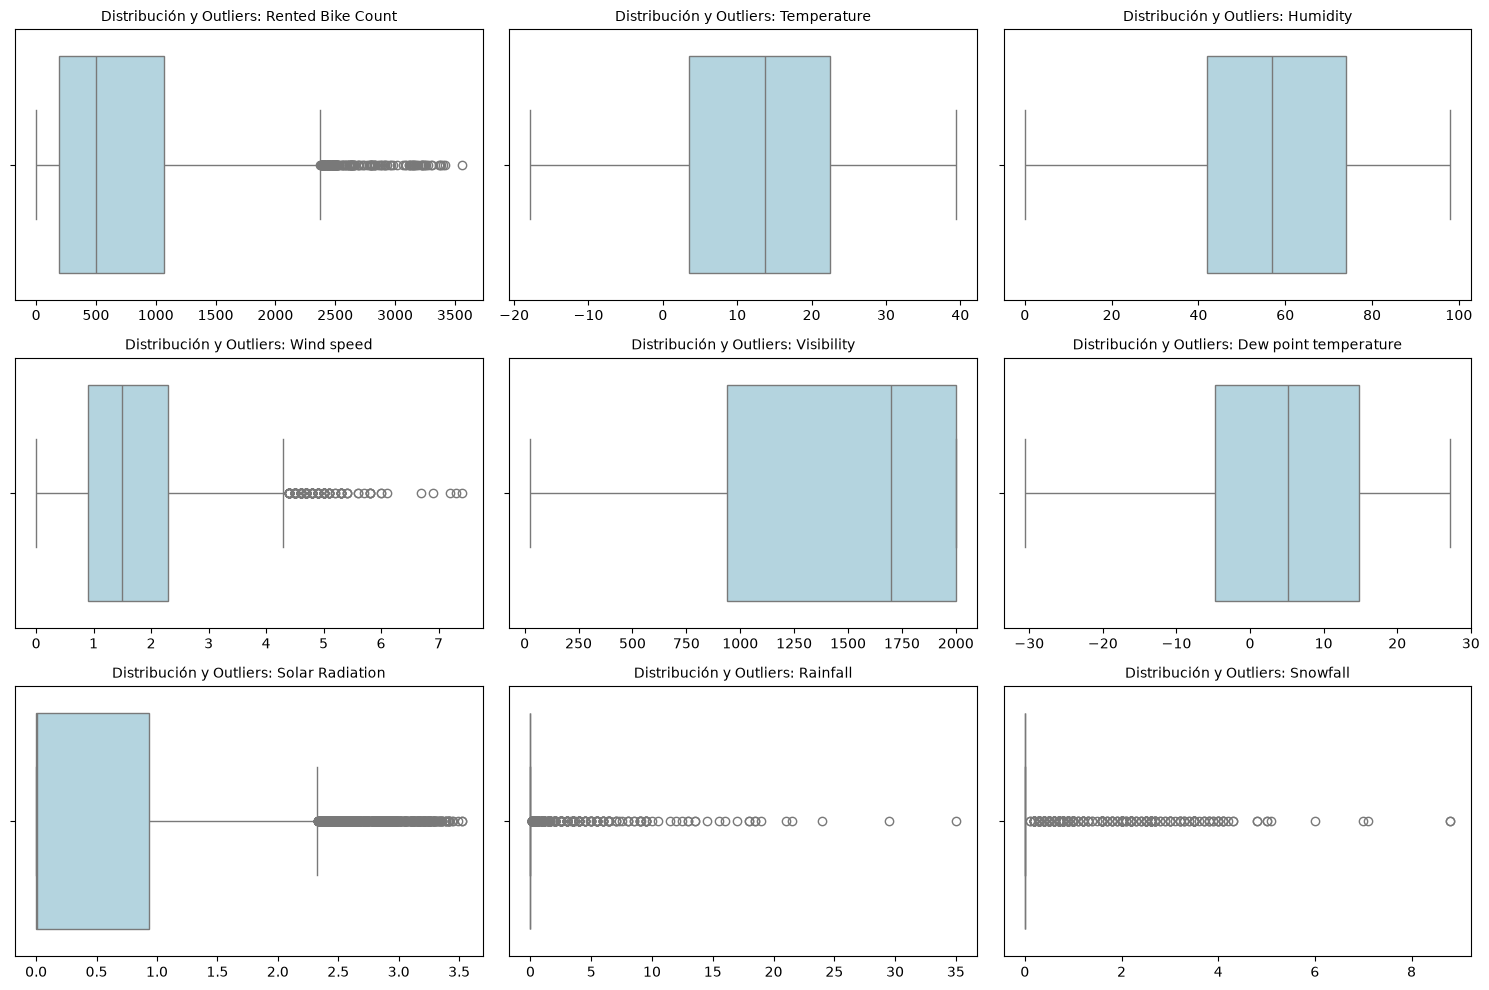

In [154]:
# Verificación de valores atípicos.
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

num_cols = ['Rented Bike Count', 'Temperature', 'Humidity', 
                'Wind speed', 'Visibility', 'Dew point temperature', 
                'Solar Radiation', 'Rainfall', 'Snowfall']

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Distribución y Outliers: {col}', fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Análisis preliminar valores atípicos**
Aparentemente muchas variables tienen valores atípicos, sin embargo, al entender el contexto del dataset entendemos que las variables pueden comportarse de manera diferente dependiente de la temporada y la hora, es por esto que con solo el diagrama de bigotes general por todos los registros y variables aún no descartamos nada.

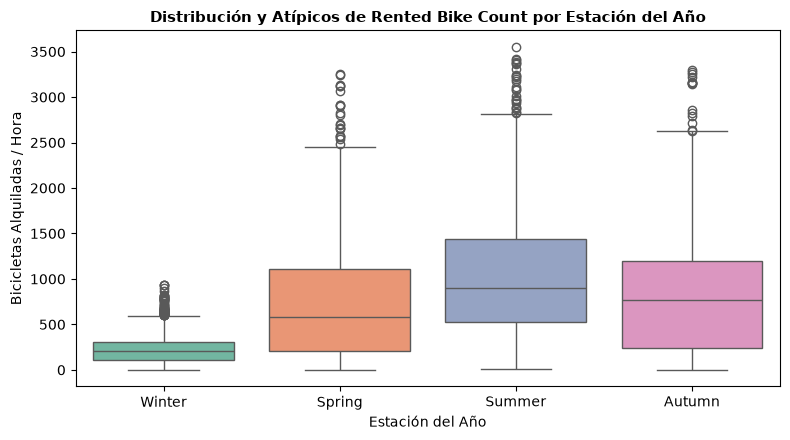

In [155]:
# Graficar la distribución de la variable objetivo 'Rented Bike Count' por estación del año
plt.figure(figsize=(8, 4.5))

# Boxplot de la variable objetivo agrupada por Seasons
sns.boxplot(
    data=df,
    x='Seasons',
    y='Rented Bike Count',
    hue='Seasons',
    palette='Set2',
    legend=False,
)

plt.title(
    'Distribución y Atípicos de Rented Bike Count por Estación del Año',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Estación del Año')
plt.ylabel('Bicicletas Alquiladas / Hora')

plt.tight_layout()
plt.show()

**Análisis de Valores Atípicos por Estación (`Seasons`)**

El desglose de la variable objetivo por estación del año confirma que lo que parecía un conjunto de "valores atípicos" globales es en realidad un efecto directo de la estacionalidad climática:

Se logra observar por medio de estos gráficos de bigotes que los datos tienen una distribución explicable por medio de las estaciones del año, ya que se logra observar como en verano tenemos los picos más altos de renta de bicicletas, mientras que en invierno tenemos los picos más bajas, aunque siguen apreciendo aparentemente valores atípicos, estos se pueden explicar con los horarios del día, lo que en mobilidad se conoce como horas pico y valle.

No se deben eliminar los valores altos de demanda. Tratar estas observaciones como *outliers* tradicionales nos podría llevar a perder la capacidad de predecir la alta demanda en ciertos periodos de tiempo. La incorporación de las variables que tenemos en el dataset nos permitirá explicar la distribución de los datos.

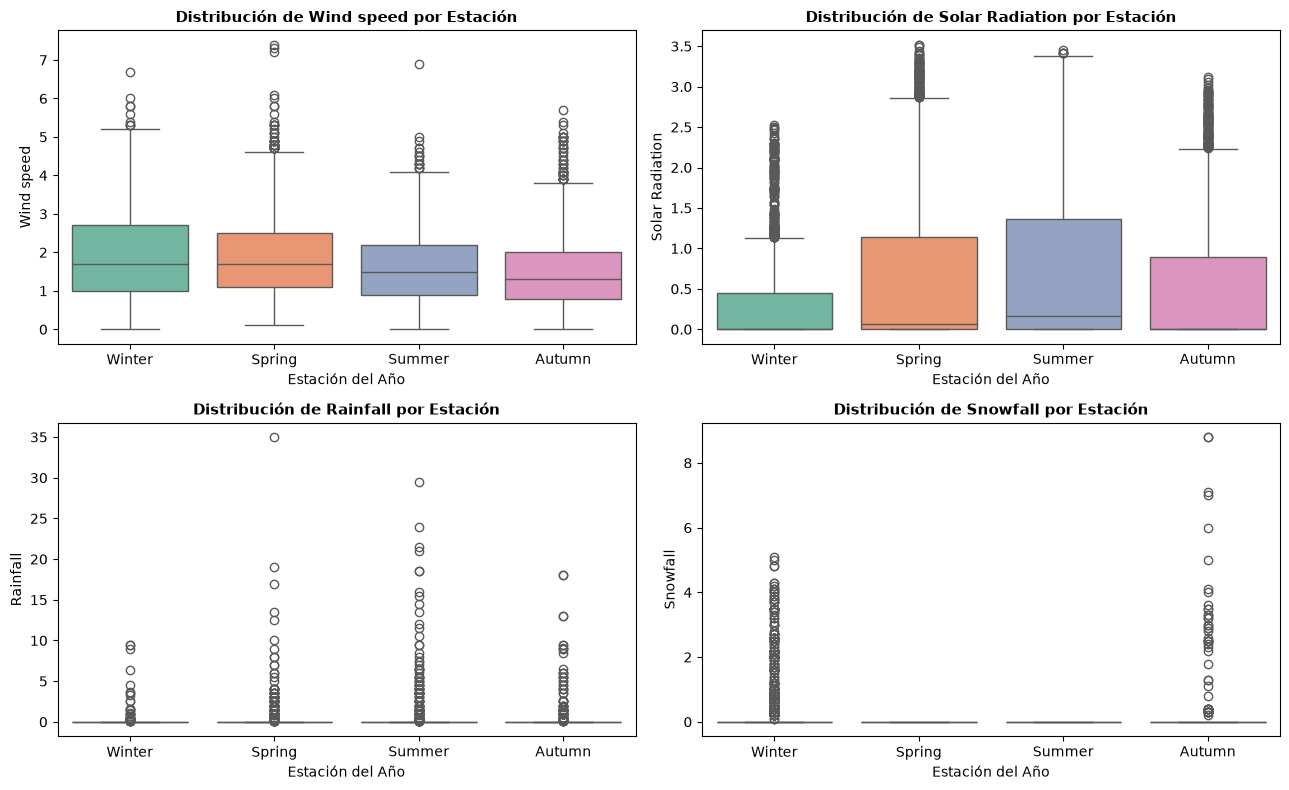

In [156]:
#Análisis de la relación entre las variables meteorológicas y la temporada del año

#Variables a analizar: Wind speed, Solar Radiation, Rainfall, Snowfall
weather_cols = ['Wind speed', 'Solar Radiation', 'Rainfall', 'Snowfall']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    sns.boxplot(
        data=df,
        x='Seasons',
        y=col,
        hue='Seasons',
        ax=axes[i],
        palette='Set2',
        legend=False,
    )
    axes[i].set_title(
        f'Distribución de {col} por Estación', fontsize=11, fontweight='bold'
    )
    axes[i].set_xlabel('Estación del Año')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

**Análisis general de valores atípicos**
Las variables al igual que la variable objetivo tienen una tendencia en relación a las temporadas del año, que aunque tienen valores atípicos no se alejan de valores con sentido, como por ejemplo nieve solo otoño e invierno o lluvias principalmente en primavera o verano.

In [157]:
#Corrección de valores inconsistentes en la variable de humedad relativa (Humidity)
zero_humidity_df = df[df['Humidity'] == 0]
print(f"Total de registros con humedad = 0: {len(zero_humidity_df)}")

# Mostrar los registros afectados con sus variables temporales y climáticas principales
zero_humidity_df[['Date', 'Hour', 'Humidity', 'Temperature', 'Seasons']]

Total de registros con humedad = 0: 17


,Date,Hour,Humidity,Temperature,Seasons
4063,19/05/2018,7,0,11.4,Spring
4106,21/05/2018,2,0,13.9,Spring
4107,21/05/2018,3,0,13.0,Spring
4108,21/05/2018,4,0,12.4,Spring
4109,21/05/2018,5,0,11.9,Spring
4110,21/05/2018,6,0,11.4,Spring
4111,21/05/2018,7,0,12.3,Spring
4131,22/05/2018,3,0,15.5,Spring
4132,22/05/2018,4,0,15.6,Spring
4133,22/05/2018,5,0,15.7,Spring


In [158]:
# Imputación de valores inconsistentes de la variable humedad con sesion y hour
# Convertir los ceros en NaN para no sesgar la mediana del grupo
df['Humidity'] = df['Humidity'].replace(0, np.nan)

# 2. Imputar con la mediana de cada combinación de Estación y Hora
df['Humidity'] = df.groupby(['Seasons', 'Hour'])['Humidity'].transform(
    lambda x: x.fillna(x.median())
)

# Confirmar que ya no hay valores en cero ni faltantes
print(f"Ceros restantes en Humidity: {(df['Humidity'] == 0).sum()}")
print(f"Nulos restantes en Humidity: {df['Humidity'].isnull().sum()}")

Ceros restantes en Humidity: 0
Nulos restantes en Humidity: 0


**Imputación de valores inconsistentes**

La humedad relativa de cero no existe en la naturaleza y solo se puede llegar a simular en un laboratorio, por esta razón imputamos los valores con cero por medio de la mediana de la agrupación de Season y hour, ya que dependiendo de la hora la humedad se comporta de manera similar, además de la temporada del año en la que se encuentre.

In [159]:
# Cálculo y clasificación de la asimetría (Skewness)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

skew_df = pd.DataFrame({
    'Variable': num_cols,
    'Skewness': df[num_cols].skew().round(2)
})

# Regla general de clasificación
def clasificar_asimetria(val):
    if val > 1:
        return 'Alta Asimetría Positiva (Sesgo a la derecha)'
    elif val < -1:
        return 'Alta Asimetría Negativa (Sesgo a la izquierda)'
    elif 0.5 <= abs(val) <= 1:
        return 'Asimetría Moderada'
    elif abs(val) == 0:
        return 'Perfectamente Simétrico'
    else:
        return 'Aproximadamente Simétrica'

skew_df['Interpretación'] = skew_df['Skewness'].apply(clasificar_asimetria)
skew_df.sort_values(by='Skewness', ascending=False, inplace=True)
skew_df.reset_index(drop=True, inplace=True)

skew_df

,Variable,Skewness,Interpretación
0,Rainfall,14.53,Alta Asimetría Positiva (Sesgo a la derecha)
1,Snowfall,8.44,Alta Asimetría Positiva (Sesgo a la derecha)
2,Solar Radiation,1.50,Alta Asimetría Positiva (Sesgo a la derecha)
3,Rented Bike Count,1.15,Alta Asimetría Positiva (Sesgo a la derecha)
4,Wind speed,0.89,Asimetría Moderada
5,Humidity,0.09,Aproximadamente Simétrica
6,Hour,0.00,Perfectamente Simétrico
7,Temperature,-0.20,Aproximadamente Simétrica
8,Dew point temperature,-0.37,Aproximadamente Simétrica
9,Visibility,-0.70,Asimetría Moderada


**Análisis de asimetría**
Al calcular la asimetría (skewness) de las variables numéricas, notamos que no todas se comportan igual. Por eso, dividimos el análisis según la forma de cada distribución para justificar qué hacer con cada una:

* **Variable Objetivo (Rented Bike Count — Skewness = 1.15)** 
Vemos un sesgo positivo claro (cola hacia la derecha). Esto ocurre porque en la mayoría de las horas los alquileres son moderados, pero en las horas pico los números se disparan. En estos casos se podría evaluar una transformación logarítmica de los datos, sin embargo es importante entender que el modelo predecirá valores logarítmico, por lo que al final tendríamos que realizar una función exponencial que nos devuelva el valor real. 

* **Lluvia y Nieve (Rainfall = 14.53 | Snowfall = 8.44):** 
Tienen una asimetría extrema hacia la derecha. Esto es esperable, ya que la lluvia y la nieve no son comunes y pasan en ciertas horas del día y temporadas con mayor frecuencia, por lo que los demás registros están llenos de ceros. Generalmente en estos horarios no se usan mucho las bicicletas, independientemente de la intensidad, por lo que conviene convertirlo a binario en cuanto a presencia o ausencia.

* **Radiación Solar (Solar Radiation — Skewness = 1.50):** 
Tiene un sesgo positivo moderado, ocasionado principalmente porque durante toda la noche el valor registrado es cero. En este caso mantenerlo es importante, lo que podríamos hacer es un proceso de escalado StandardScaler, para encoger los datos, pero mantener su distribución.

* **Variables Atmosféricas Continuas (Temperature, Humidity, Dew point temperature — Skewness entre -0.24 y 0.08):** 
Sus coeficientes están muy cercanos a cero, lo que nos indica que sus distribuciones son bastante simétricas y no presentan sesgos importantes. A estas podemos solo aplicarles estandarizaciones como StandardScaler para que no afecte la distribución de la variable y la magnitud no esté inflada para los análisis posteriores.


## 4. Análisis exploratorio

Para entender mejor las variables y la relación entre ellas, realizamos un estudio descriptivo mediante:

- estadísticos descriptivos;
- histogramas;
- diagramas de caja;
- correlaciones;
- análisis bivariante.

En esta sección realizamos un Análisis Exploratorio de Datos (EDA) para comprender el comportamiento de las variables, identificar patrones de consumo en el alquiler de bicicletas y detectar relaciones entre los factores meteorológicos y temporales.

---

In [160]:
# Estadísticos descriptivos detallados para variables numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['skewness'] = df[num_cols].skew()

# Reorganizamos columnas para facilitar lectura
stats_df = stats_df[['count', 'mean', 'std', 'median', 'min', '25%', '50%', '75%', 'max', 'skewness']].round(2)
stats_df

,count,mean,std,median,min,25%,50%,75%,max,skewness
Rented Bike Count,8760.0,704.60,645.00,504.50,0.0,191.00,504.50,1065.25,3556.00,1.15
Hour,8760.0,11.50,6.92,11.50,0.0,5.75,11.50,17.25,23.00,0.00
Temperature,8760.0,12.88,11.94,13.70,-17.8,3.50,13.70,22.50,39.40,-0.20
Humidity,8760.0,58.37,20.21,57.00,10.0,43.00,57.00,74.00,98.00,0.09
Wind speed,8760.0,1.72,1.04,1.50,0.0,0.90,1.50,2.30,7.40,0.89
Visibility,8760.0,1436.83,608.30,1698.00,27.0,940.00,1698.00,2000.00,2000.00,-0.70
Dew point temperature,8760.0,4.07,13.06,5.10,-30.6,-4.70,5.10,14.80,27.20,-0.37
Solar Radiation,8760.0,0.57,0.87,0.01,0.0,0.00,0.01,0.93,3.52,1.50
Rainfall,8760.0,0.15,1.13,0.00,0.0,0.00,0.00,0.00,35.00,14.53
Snowfall,8760.0,0.08,0.44,0.00,0.0,0.00,0.00,0.00,8.80,8.44


**Análisis descriptivo**

**Alta Volatilidad de la Demanda:** La desviación estándar de la demanda (645.00) es casi igual que su promedio (704.60). Esto evidencia un sistema de transporte con alta variabilidad, pasando de horas valle con bajísima actividad a momentos de alta saturación en las estaciones. Además de tener en cuenta que existen horas durante el día que el uso de las mismas puede llegar a cero. Además notamos que la demanda habitual ronda los 504.50, en relación a su mediana que suaviza un poco las horas con 0 de demanda.

**Precipitaciones (Rainfall y Snowfall):** El percentil 75 es de 0 en ambas variables, lo que confirma que en más del 75\% de las horas del año no se registran lluvias ni nevadas. 

**Radiación Solar (Solar Radiation):** Su mediana es de 0.01 MJ/m^2, lo cual concuerda con la gran cantidad de resgistros correspondientes a la noche (sin luz solar).

**Visibilidad (Visibility):** El 50\% de los datos se encuentra sobre los 1,698m y alcanza un máximo de 2,000m, reflejando una buena visibilidad la mayor parte del año.

**Amplitud Térmica:** La diferencia entre la temperatura mínima (-17.8C) y máxima (39.4C) es de 57.2C, Una diferencia grande, pero que al análizarlo por estaciones posiblemente se explique de una mejor manera.

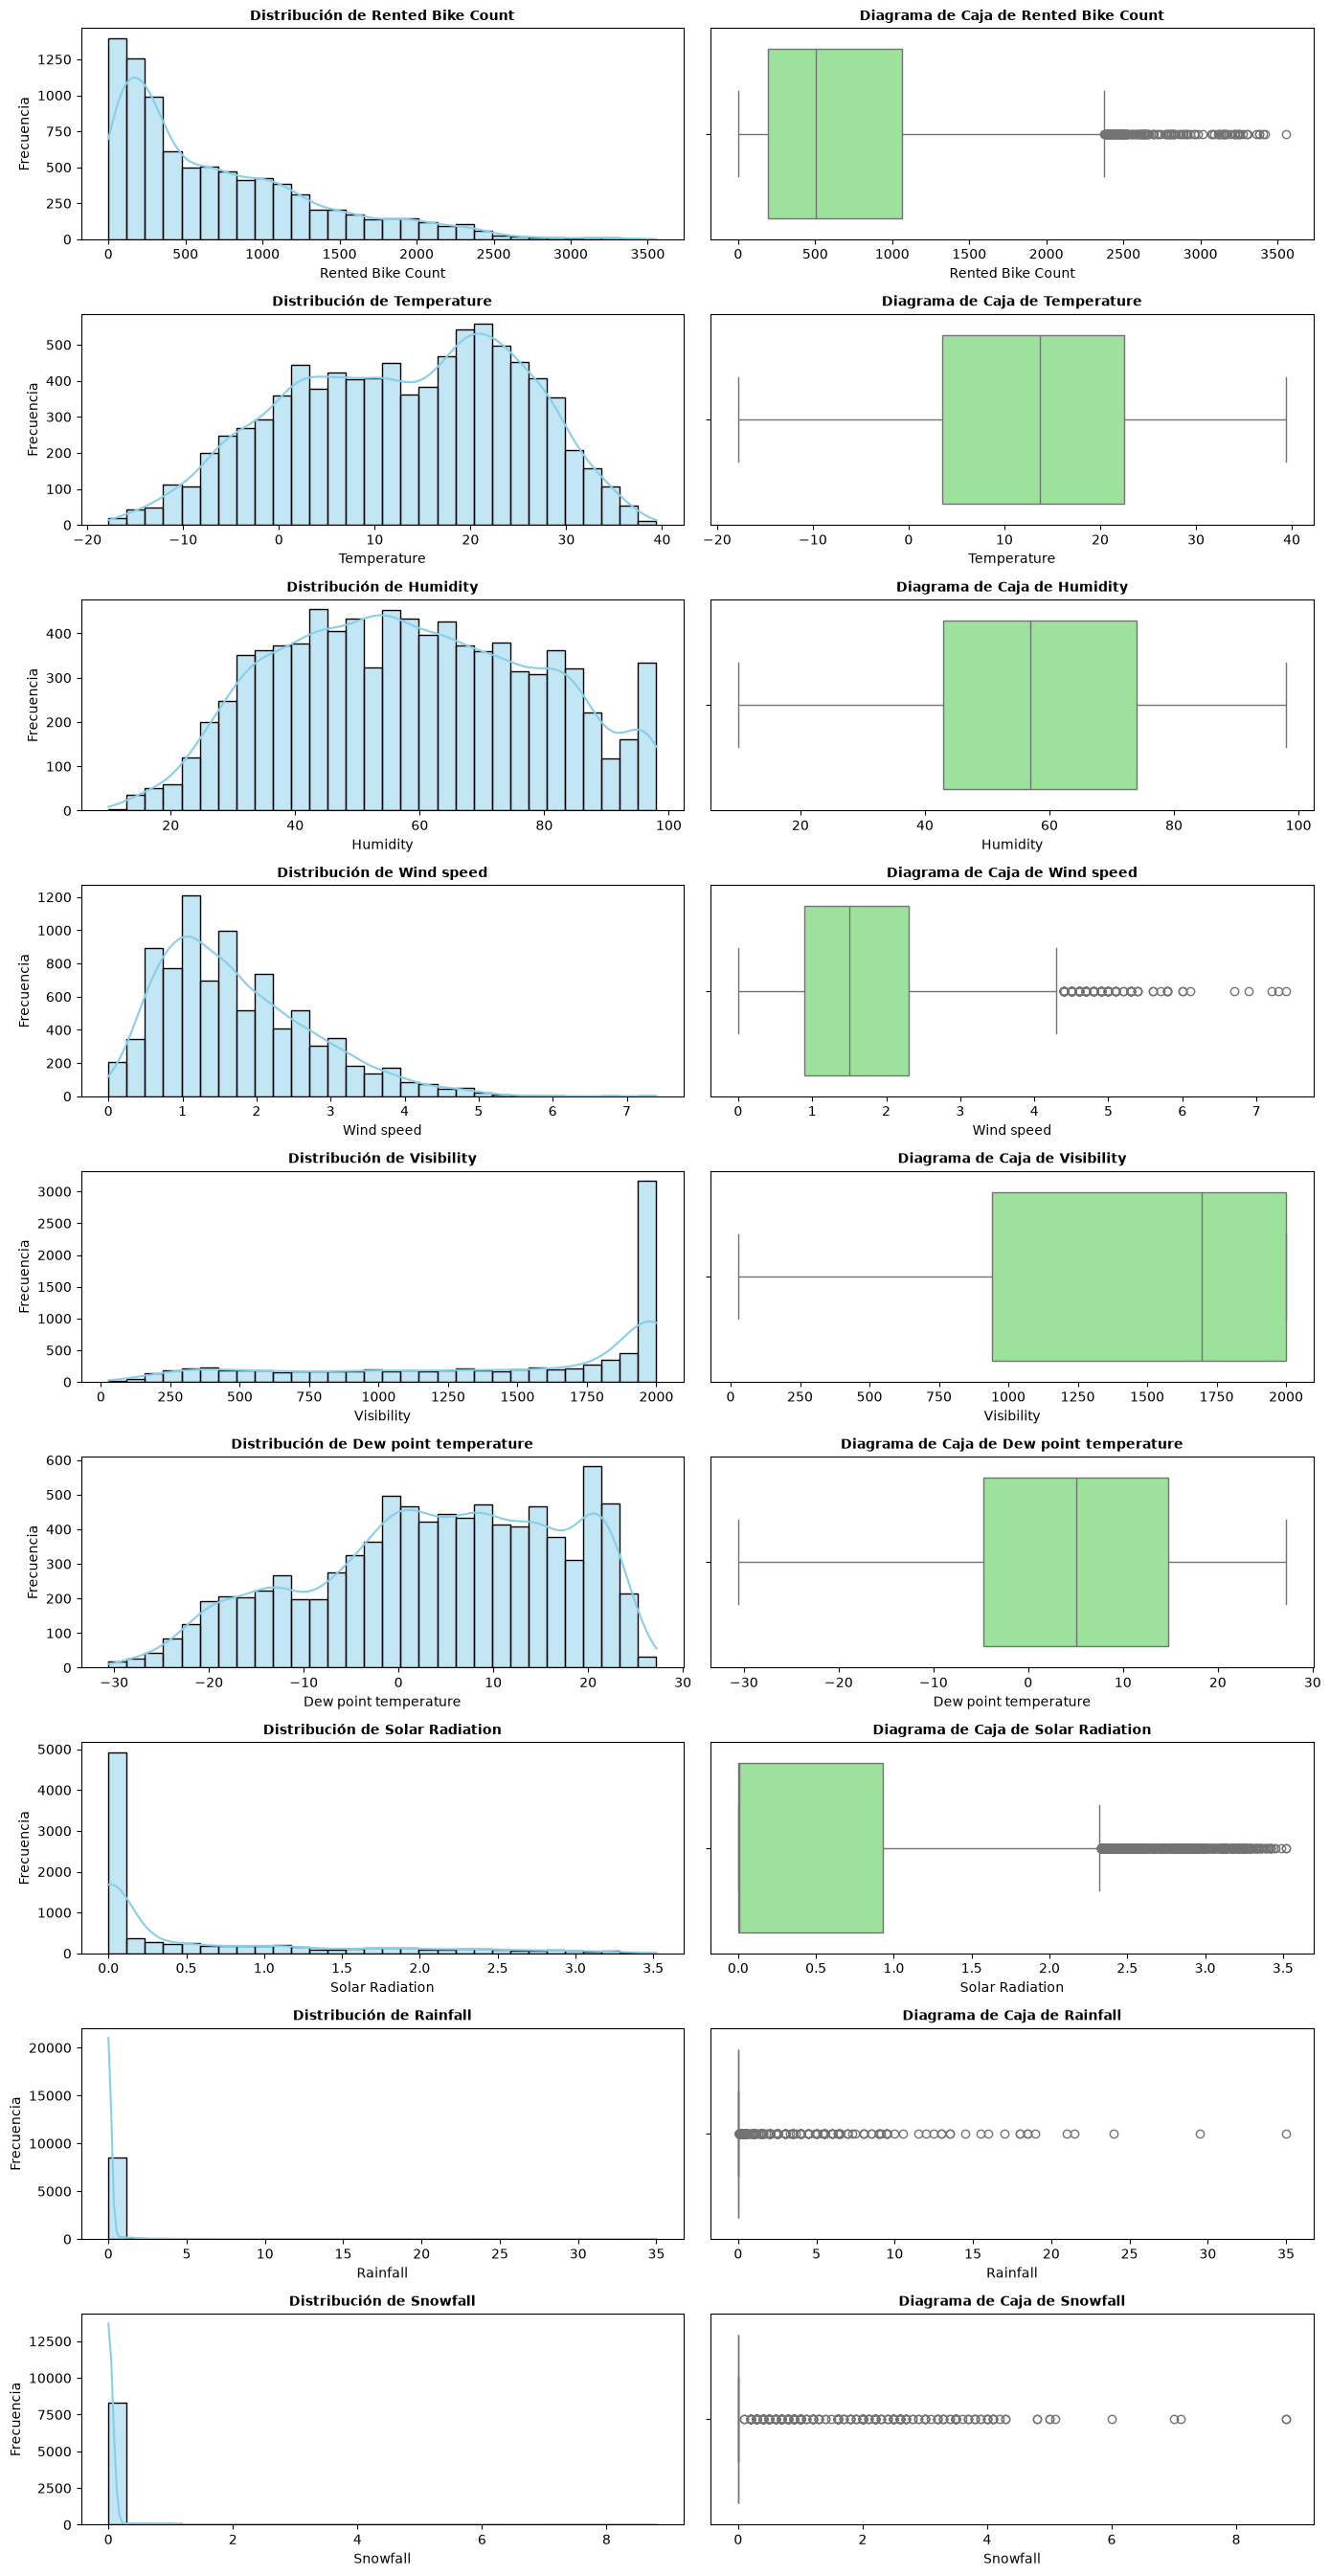

In [161]:
# Lista de todas las variables numéricas continuas
cols_to_plot = [
    'Rented Bike Count',
    'Temperature',
    'Humidity',
    'Wind speed',
    'Visibility',
    'Dew point temperature',
    'Solar Radiation',
    'Rainfall',
    'Snowfall',
]

n_cols = len(cols_to_plot)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3 * n_cols))

for i, col in enumerate(cols_to_plot):
  # Histograma con estimación de densidad (KDE)
  sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', bins=30)
  axes[i, 0].set_title(
      f'Distribución de {col}', fontsize=10, fontweight='bold'
  )
  axes[i, 0].set_ylabel('Frecuencia')

  # Diagrama de caja (Boxplot)
  sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
  axes[i, 1].set_title(
      f'Diagrama de Caja de {col}', fontsize=10, fontweight='bold'
  )

plt.tight_layout()
plt.show()

**Análisis de histogramas y diagramas de cajas**

Como se analizó previamente, el comportamiento numérico de las variables encuentra una confirmación gráfica directa al observar sus histogramas y diagramas de caja:

A diferencia del análisis de nivel de asimetría numérico al observar gráficamente la distribución de los datos por medio de un histograma y al mismo tiempo por medio del diagrama de bigotes, podemos comprender mejor el tema de los valores atípicos. Por ejemplo en las variables Rented Bike Count y Solar Radiation podemos observar la gran cantidad de registros en cero, lo cual puede estar relaciona, ya que en altas horas de la noche, no se usan las bicicletas generalmente. Al concentrarse tantos registros en cero, las medidas de tendencia central se van a ubicar al inicio de los valores, por lo que los valores que deberían ser normales se catalogan como atípicos.

Por otro lado, confirmando lo de Rainfall y Snowfall, las cuales la mayor parte del año son cero y aumentan en ciertas temporadas del año de manera esporádica, razón por la cual, casi todos los valores diferentes a cero son clasificados como atípicos.

Las demás variables no tienen una asimetría tan marcada, lo que confirma el análisis previo y confirma las transformaciones que deberíamos hacer principalmente con StandardScaler() en la mayoría de ellas.

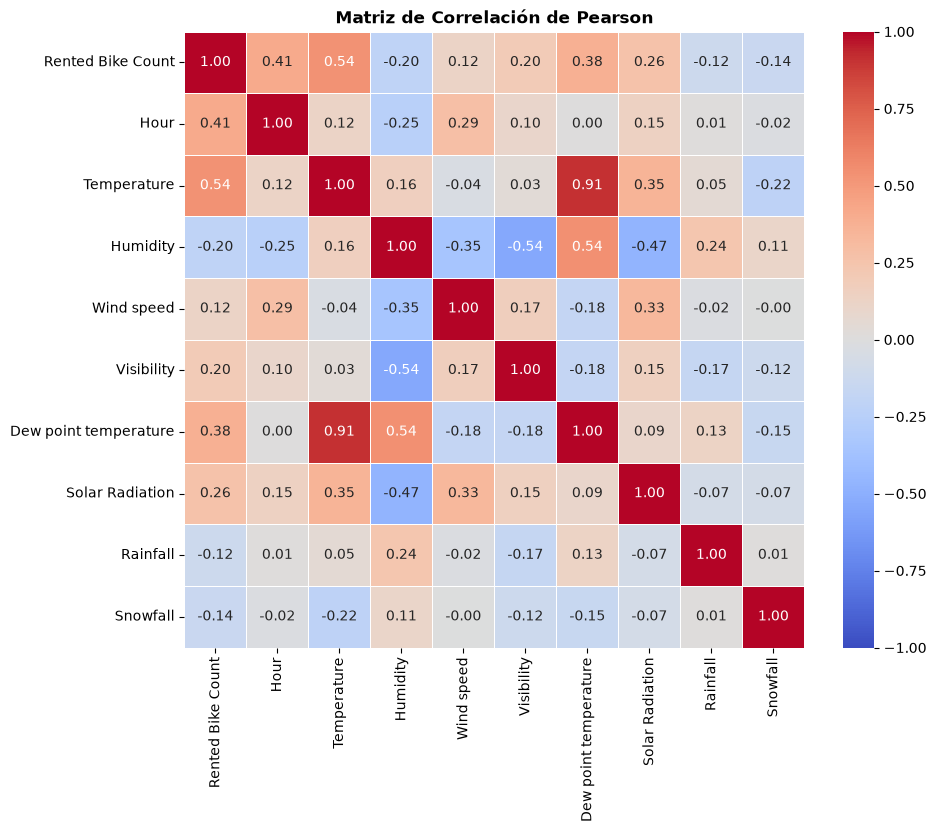

In [162]:
# Matriz de correlación de Pearson entre variables numéricas
plt.figure(figsize=(10, 8))

corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title('Matriz de Correlación de Pearson', fontsize=12, fontweight='bold')
plt.show()

**Análisis de Matriz de Correlación de Pearson**

A partir de la matriz de correlación de Pearson obtenida, analizamos cómo se relacionan las variables numéricas tanto con la demanda de bicicletas como entre ellas mismas:

* **Relación con la Variable Objetivo (Rented Bike Count)**

Temperature (r = 0.54): Es la variable con mayor correlación positiva con la demanda. Esto confirma que los días más cálidos incentivan directamente el uso de las bicicletas.

Hour (r = 0.41): Muestra una relación positiva moderada, reflejando el incremento del alquiler a medida que avanza la jornada hacia las horas pico.

Dew point temperature (r = 0.38) y Solar Radiation (r = 0.26): Ambas se relacionan con el comportamiento térmico y la presencia de luz solar, lo que favorece el uso del servicio.

Las demás variables tienen una correlación debil, donde vale la pena resaltar la lluvia y la nieve, las cuales tienen esta baja correlación causada principalmente por la gran cantidad de registros en cero. 

 * **Relación de las variables entre sí**

Temperature vs. Dew point temperature (r = 0.91):Existe una correlación lineal extremadamente alta entre la temperatura del aire y la temperatura del punto de rocío, esto se debe a que al aumentar la temperatura promedio aumenta la cantidad de agua que se evapora, por lo que al tener mayor agua el aire se aumenta el la temperatura del punto de rocio, esto podría explicar la colinealidad, por lo que valdria la pena mantener solo la variable con mayor correlación a la variable objetivo que es la temperatura.

Las otras variables climatológicas aunque tienen correlación, no son lo suficientemente altas como para considerar que existe cierto grado de colinealidad, sino que se relacionan de manera natural con cierta causalidad que no afecta nuestro análisis y corresponden a dinámicas normales.

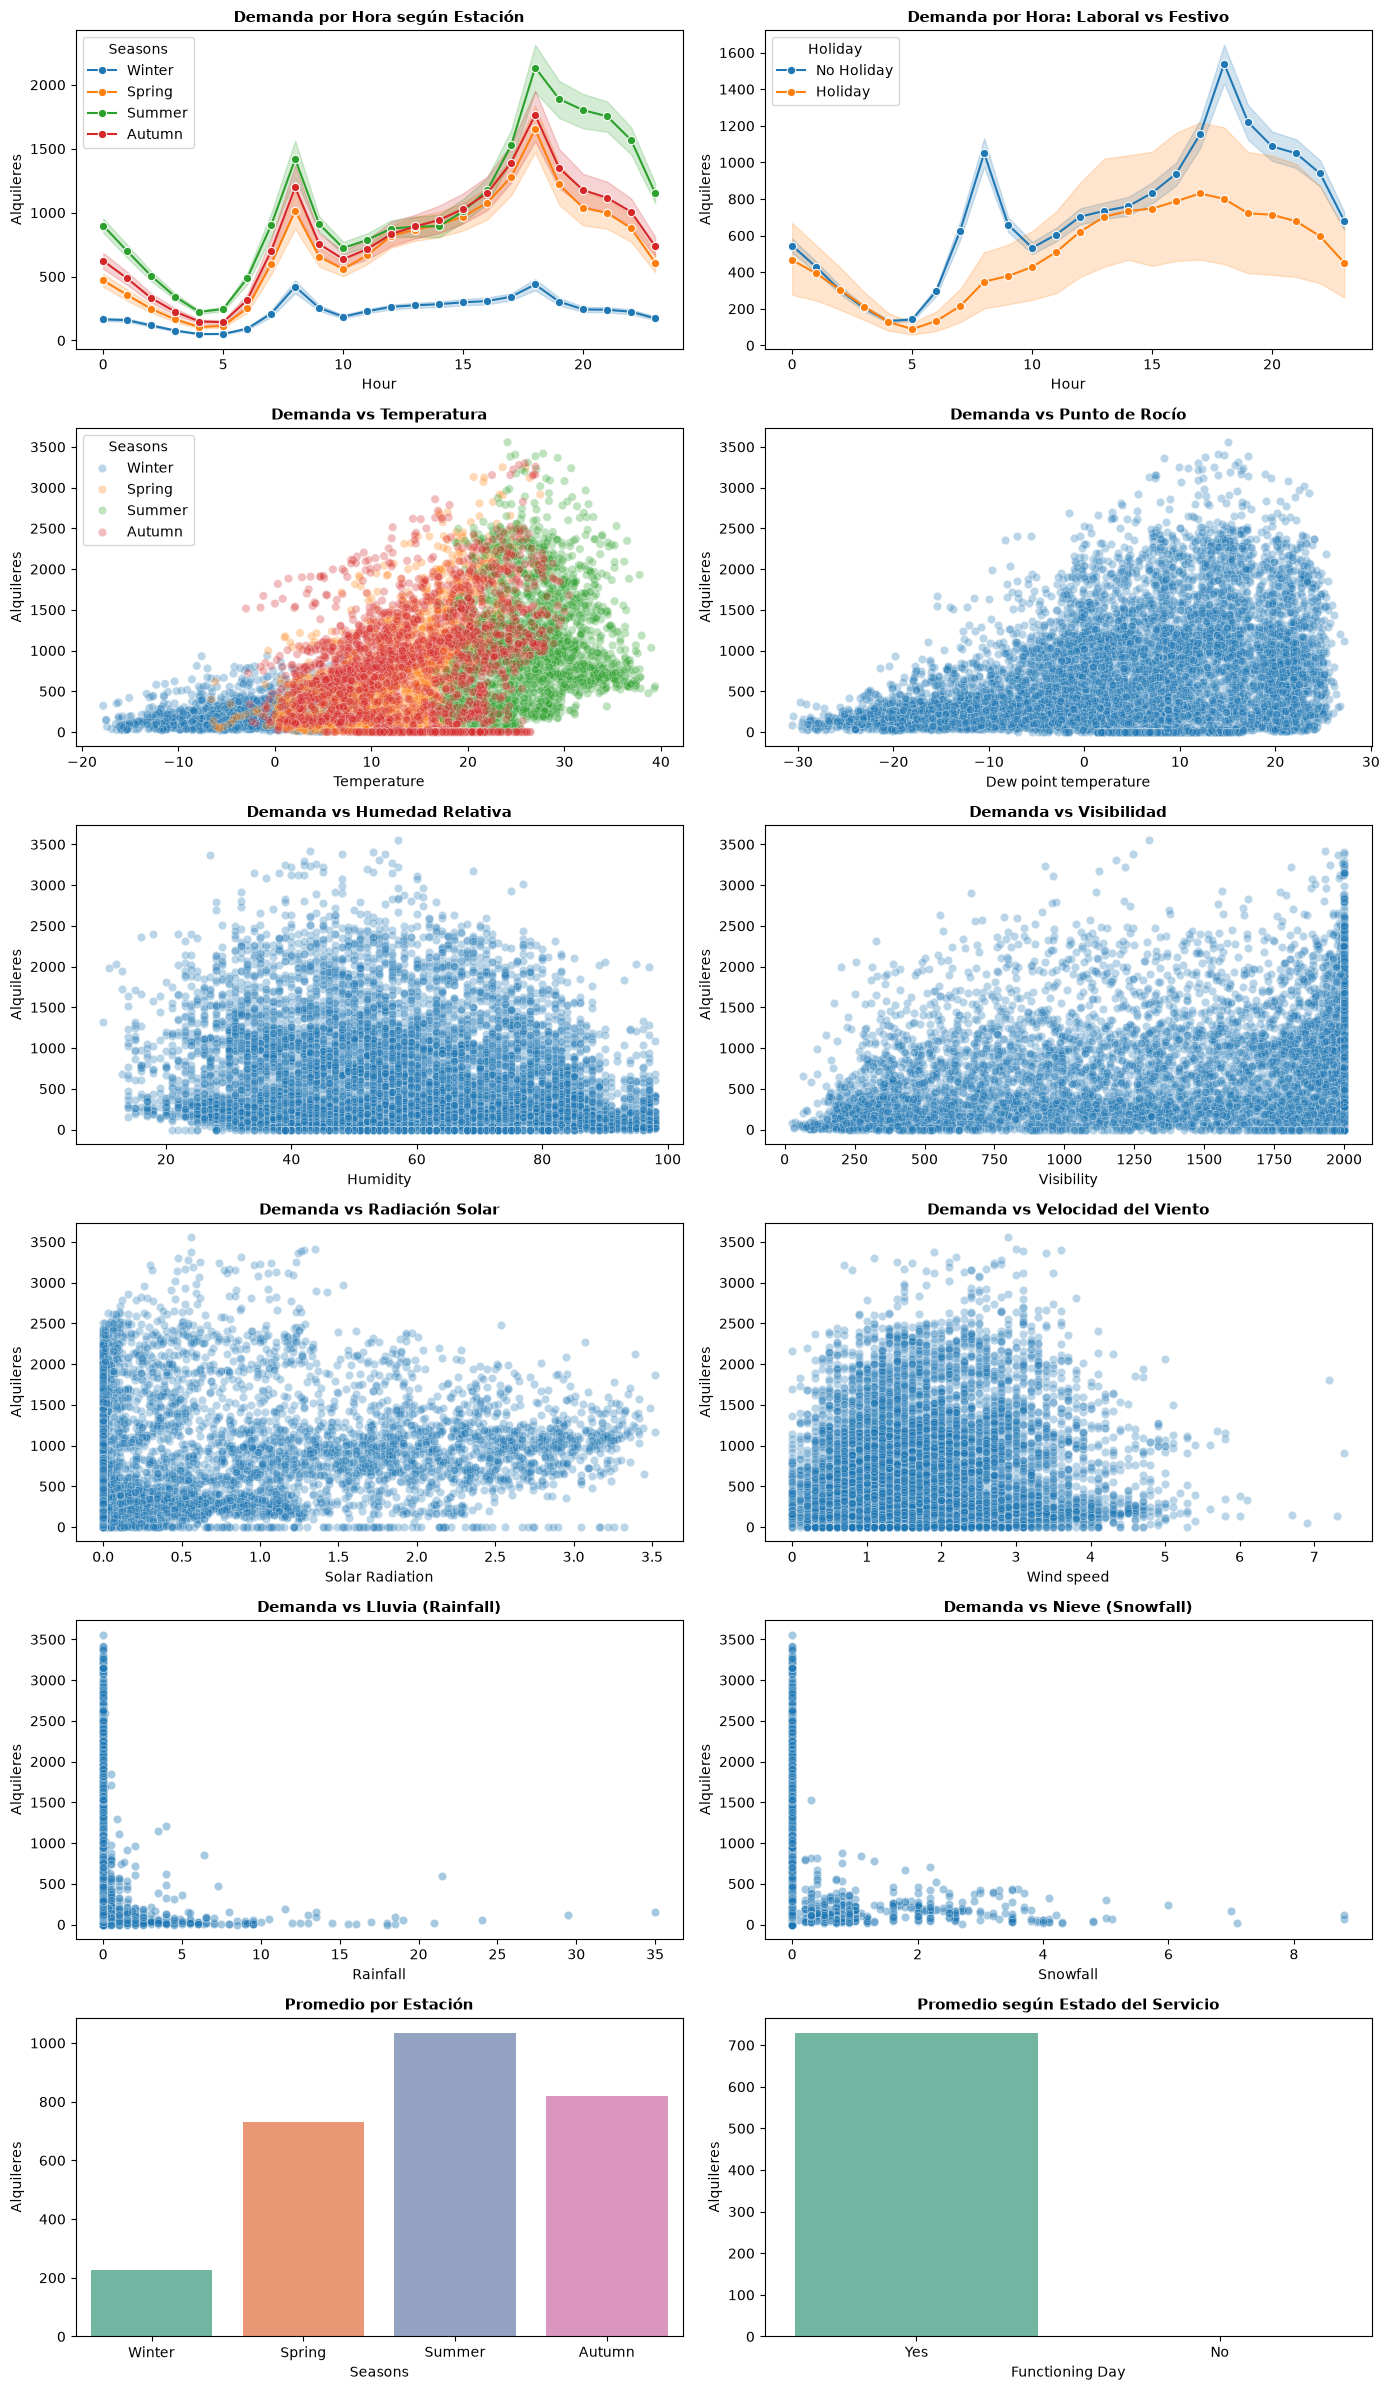

In [163]:
# Gráficos de análisis bivariante
plots = [
    (
        'Hour',
        'Seasons',
        sns.lineplot,
        'Demanda por Hora según Estación',
        {'marker': 'o'},
    ),
    (
        'Hour',
        'Holiday',
        sns.lineplot,
        'Demanda por Hora: Laboral vs Festivo',
        {'marker': 'o'},
    ),
    (
        'Temperature',
        'Seasons',
        sns.scatterplot,
        'Demanda vs Temperatura',
        {'alpha': 0.3},
    ),
    (
        'Dew point temperature',
        None,
        sns.scatterplot,
        'Demanda vs Punto de Rocío',
        {'alpha': 0.3},
    ),
    (
        'Humidity',
        None,
        sns.scatterplot,
        'Demanda vs Humedad Relativa',
        {'alpha': 0.3},
    ),
    (
        'Visibility',
        None,
        sns.scatterplot,
        'Demanda vs Visibilidad',
        {'alpha': 0.3},
    ),
    (
        'Solar Radiation',
        None,
        sns.scatterplot,
        'Demanda vs Radiación Solar',
        {'alpha': 0.3},
    ),
    (
        'Wind speed',
        None,
        sns.scatterplot,
        'Demanda vs Velocidad del Viento',
        {'alpha': 0.3},
    ),
    (
        'Rainfall',
        None,
        sns.scatterplot,
        'Demanda vs Lluvia (Rainfall)',
        {'alpha': 0.4},
    ),
    (
        'Snowfall',
        None,
        sns.scatterplot,
        'Demanda vs Nieve (Snowfall)',
        {'alpha': 0.4},
    ),
    (
        'Seasons',
        'Seasons',
        sns.barplot,
        'Promedio por Estación',
        {'palette': 'Set2', 'errorbar': None},
    ),
    (
        'Functioning Day',
        'Functioning Day',
        sns.barplot,
        'Promedio según Estado del Servicio',
        {'palette': 'Set2', 'errorbar': None},
    ),
]

# Ajustamos la figura a 6 filas x 2 columnas para albergar las 12 gráficas
fig, axes = plt.subplots(6, 2, figsize=(14, 24))

for ax, (x, hue, func, title, kwargs) in zip(axes.flat, plots):
  func(data=df, x=x, y='Rented Bike Count', hue=hue, ax=ax, **kwargs)
  ax.set_title(title, fontweight='bold', fontsize=11)
  ax.set_ylabel('Alquileres')

plt.tight_layout()
plt.show()

**Interpretación del Análisis Bivariante**

* **Patrones Temporales y Movilidad Urbana**

La curva exhibe dos picos muy marcados: el primero a las **8:00 AM** y el segundo (más alto) entre las **5:00 PM y 7:00 PM**. Esto evidencia un uso predominantemente del sistema como medio de transporte para ir al trabajo. Mientras que en los días festivos los picos en la mañana desaparecen y la demanda crece de manera continua desde las 10:00 AM hasta alcanzar un máximo suave durante la tarde (2:00 PM a 6:00 PM), lo que sugiere un uso recreativo.

* **Variables Climáticas Principales**

**Temperatura:** La demanda crece con una tendencia positiva a medida que la temperatura aumenta, sin embargo en temperaturas extremas aunque existe alta demanda la frecuencia disminuye considerablemente. Podemos observar una zona de confort apróximada entre 5 y cercano a los 30 grados.

* **Humedad Relativa:** A partir del 70% de humedad, la densidad de puntos de alta demanda cae sustancialmente. Niveles extremas de humedad (cercanos al 100%) se asocian con valores de alquiler muy bajos, posiblemente causado por lluvias.

* **Radiación Solar:** La demanda aumenta en horas de sol moderado o bajas. Sin embargo, la dispersión muestra que incluso en ausencia de radiación (horario nocturno) se mantiene un volumen considerable de uso impulsado por el regreso laboral.

**Factores Ambientales Secundarios**
* El uso de las bicicletas es mayor con velocidades del viento medios, cuando presentamos velocidades de viento mayores a 5 disminuye considerablemente, lo que se relaciona con dificultad para pedalear y posiblemente condiciones climáticas adversas. Por otro lado a mayor visibilidad aumenta el uso de las bicicletas lo que se puede relacionar de igual manera con temporadas climáticas óptimas.

**Variables Categóricas y Estado de Operación**
* **Estaciones:** Verano y Otoño registran los valores más altos de alquiler, seguidos por Primavera. Mientras que en Invierno, el volumen total se reduce a menos de un tercio, lo que se relaciona con la temperatura y las condiciones climáticas adversas para los usuarios.

* **Functioning Day:** Se ratifica de forma contundente que cuando Functioning Day == 'No', la demanda es exactamente 0 en el 100% de los casos. Esto valida la decisión de filtrar estos registros antes del entrenamiento para no tener sesgos de ceros forzados al modelo.

## Fase de transformación

En esta etapa se realizarán las transformación necesarias en el dataset para generar la vista minable previo al proceso de modelación.

In [164]:
# Crear una copia de respaldo
df_prep = df.copy()

# Dimensiones del DataFrame antes de filtrar
print("Dimensiones del DataFrame antes de filtrar días fuera de servicio:") 
print(df_prep.shape)

# Filtrar días fuera de servicio
df_prep = df_prep[df_prep['Functioning Day'] == 'Yes'].reset_index(drop=True)

# Dimensiones del DataFrame después de filtrar
print("Dimensiones del DataFrame después de filtrar días fuera de servicio:") 
print(df_prep.shape)

# registros eliminados
print(f"Total de registros eliminados: {df.shape[0] - df_prep.shape[0]}")


Dimensiones del DataFrame antes de filtrar días fuera de servicio:
(8760, 14)
Dimensiones del DataFrame después de filtrar días fuera de servicio:
(8465, 14)
Total de registros eliminados: 295


In [165]:
# Binarizar precipitaciones
df_prep['Rainfall_binary'] = (df_prep['Rainfall'] > 0).astype(int)
df_prep['Snowfall_binary'] = (df_prep['Snowfall'] > 0).astype(int)

# Eliminar variables redundantes, colineales y originales transformadas en otro campo
cols_to_drop = [
    'Dew point temperature',
    'Functioning Day',
    'Date',
    'Rainfall',
    'Snowfall',
]
df_prep = df_prep.drop(columns=cols_to_drop)

print("Se han eliminado las siguientes columnas: ", cols_to_drop)

Se han eliminado las siguientes columnas:  ['Dew point temperature', 'Functioning Day', 'Date', 'Rainfall', 'Snowfall']


In [166]:
# Codificación de variables categóricas
df_prep['Holiday'] = df_prep['Holiday'].map({'Holiday': 1, 'No Holiday': 0})

# One-Hot Encoding con drop_first=True:
# Convierte 'Seasons' en variables numéricas (0 y 1) omitiendo la primera categoría ('Autumn')
# para que sirva como nivel de referencia implícito (si Spring=0, Summer=0, Winter=0 -> es Otoño).
# Esto evita la multicolinealidad perfecta, garantizando
# la estabilidad matemática en modelos de regresión lineal, Ridge y Lasso.
df_prep = pd.get_dummies(
    df_prep, columns=['Seasons'], drop_first=True, dtype=int
)

# Transformación logarítmica de la Variable Objetivo
y = np.log1p(df_prep['Rented Bike Count']) # Transformación logarítmica para reducir la asimetría y estabilizar la varianza
X = df_prep.drop(columns=['Rented Bike Count']) # Almacenamos las variables explicativas en X, excluyendo la variable objetivo

# División Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalado con StandardScaler para variables explicativas numéricas continuas
num_features = [
    'Temperature',
    'Humidity',
    'Wind speed',
    'Visibility',
    'Solar Radiation',
    'Hour',
]

# Instanciamos el objeto StandardScaler
scaler = StandardScaler()

# fit_transform en TRAIN: Aprende la escala (media/std) de entrenamiento y la aplica
X_train[num_features] = scaler.fit_transform(X_train[num_features])
# transform en TEST: Usa la misma escala aprendida en TRAIN sin ser afectado por los datos de TEST
X_test[num_features] = scaler.transform(X_test[num_features])

# Validación de dimensiones finales
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

# Verificación de la vista minable
print(f"Primeros 5 registros de X_train:\n{X_train.head()}")

Dimensiones de X_train: (6772, 12)
Dimensiones de X_test: (1693, 12)
Primeros 5 registros de X_train:
          Hour  Temperature  Humidity  Wind speed  Visibility  Solar Radiation  Holiday  Rainfall_binary  Snowfall_binary  Seasons_Spring  Seasons_Summer  Seasons_Winter
8396 -1.229214    -0.771087 -1.003057   -0.121868   -0.855495        -0.654906        0                0                0               0               0               0
5994  0.945390     1.270134  1.350303    0.553254   -0.303924        -0.332707        0                1                0               0               1               0
4740  0.075548     1.295027 -0.659859    0.456808   -1.277767         2.705170        0                0                0               0               1               0
6526  1.525284     0.938228  1.056133   -0.796990    0.691197        -0.654906        0                0                0               0               1               0
3692  1.235337     0.108464 -0.610831    1.61416

**Justificación del Preprocesamiento**

* **Filtrado de días sin servicio:** Se eliminaron los días en que el sistema no operó para evitar que los ceros forzados generen ruido en nuestros modelos, dado que en esos casos no depende de las condiciones de las variables, sí no solo sí es un día de mantenimiento o algo parecido.

* **Binarización de lluvia y nieve:** Se transformaron a 1 (hubo) o 0 (no hubo). Lo relevante para el modelo es saber si llovió o nevó, no la cantidad exacta.

* **Eliminación de variables redundantes:** Se descartó Dew point temperature por la colinealidad con la temperatura ambiente, y Date por no ser de interés para nuestro objetivo y a la vez redundante ya que tenemos la hora y la temporada que son los datos que nos interesan.

* **Codificación de categorías:** Se convirtieron Holiday y Seasons a números. Holiday como binario, siendo 1 que es holiday. En estaciones se excluyó Otoño (drop_first=True) para no entregar información matemática duplicada; eliminar Otoño elimina la redundancia matemática sin perder nada de información, y deja a Otoño como el punto neutro de comparación para las demás estaciones.

* **Transformación logarítmica log1p:** Se aplicó a la cantidad de bicicletas alquiladas para reducir los picos altos y hacer que los datos sean más estables y fáciles de predecir.

* **Escalado estándar sin fuga de datos:** Se puso a todas las variables numéricas en la misma escala. Se usó fit_transform en Train para calcular las estadísticas del grupo de datos (promedio y dispersión) y aplica el ajuste en ese mismo instante. Luego se aplica solo transform en Test para aplicar únicamente las estadísticas que ya fueron calculadas en un paso anterior y con eso no recalculamos con los datos que vamos a predecir.

## 5. Modelos de regresión

Ahora que hemos construido la vista minable, nos disponemos a construir distintos modelos predictivos para estimar el número de bicicletas alquiladas. Iniciaremos inicialmente con:

- Regresión lineal.
- Regresión polinómica.
- Ridge.
- Lasso.

Además con el fin de ser objetivos, vamos a evaluar mediante métricas apropiadas e interpretaremos las diferencias observadas.

---

In [167]:
# Definir los modelos a comparar
models = {
    'Regresión Lineal': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.01),
}

results = []

# Bucle de entrenamiento y evaluación
for name, model in models.items():
    # Entrenar el modelo con datos en escala logarítmica
    model.fit(X_train, y_train)

    # Predecir en Test
    y_pred_log = model.predict(X_test)

    # Invertir la transformación logarítmica para obtener valores reales (bicicletas)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # Calcular métricas en unidades reales
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    results.append(
        {'Modelo': name, 'RMSE (Bicicletas)': rmse, 'MAE': mae, 'MSE': mse, 'R²': r2}
    )

# Consolidar resultados en un DataFrame
df_results = pd.DataFrame(results)
print(df_results)

             Modelo  RMSE (Bicicletas)         MAE            MSE        R²
0  Regresión Lineal         416.854645  268.887153  173767.794959  0.557377
1        Ridge (L2)         416.969320  268.963406  173863.413804  0.557133
2        Lasso (L1)         428.330818  277.811258  183467.289870  0.532670


**Interpretación de los modelos:**

$R^2$ (Coeficiente de Determinación): La Regresión Lineal y Ridge logran explicar el 55.7% de la variabilidad en la demanda de bicicletas. Siendo la regresión lineal la que mejor explica la renta de bicicletas, según las variables explicativas o independientes.

MAE (Error Absoluto Medio): En promedio, las predicciones del modelo se desvían por 269 bicicletas por hora respecto a la realidad. Siendo nuevamente la regresión lineal la que se aleja menos con 268,88. Mientras que la Lasso es la que más se aleja.

MSE y RMSE (Error Cuadrático Medio (MSE) y Raíz del Error Cuadrático Medio (RMSE)):
El MSE actúa como un mecanismo de penalización, elevando los errores al cuadrado para castigar severamente los fallos en picos de demanda. Sin embargo el RMSE al ser la raiz cuadrada lo deja en las mismas unidades de la variable objetivo, este es considerablemente mayor al MAE, por esta razón confirmamos que todos los modelos tienen problemas al identificar los valores atípicos en los horarios de alta demanda.

Comparación entre Modelos: La Regresión Lineal y Ridge ofrecen rendimientos casi idénticos, siendo mejor la regresión lineal por muy poco. Esto tiene sentido porque la regresión Ridge aplica un ajuste suave sobre las variables. Por otro lado Lasso al ser más drástico y reduciendo el peso de algunas variables afectó considerablemente la capacidad de predicción de la regresión.



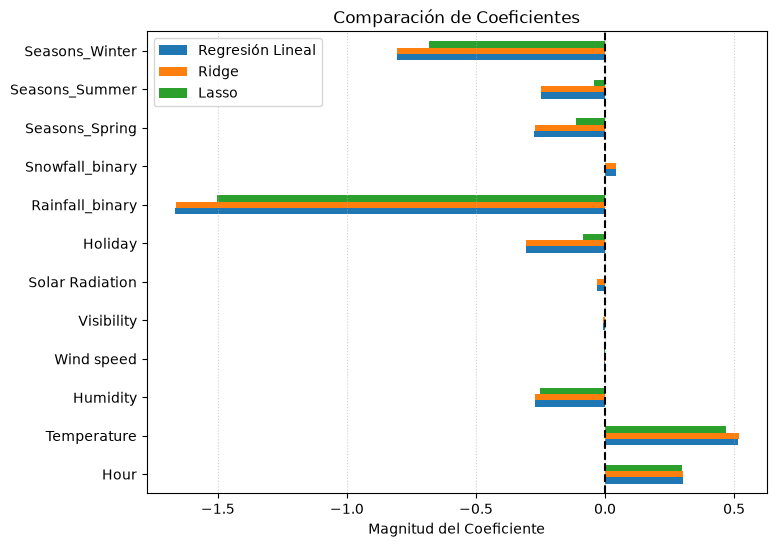

                 Regresión Lineal     Ridge     Lasso
Hour                     0.303657  0.303564  0.300008
Temperature              0.516928  0.517111  0.467660
Humidity                -0.271972 -0.272233 -0.252993
Wind speed              -0.004784 -0.004938 -0.005922
Visibility              -0.009198 -0.008963  0.004070
Solar Radiation         -0.030974 -0.030911 -0.000000
Holiday                 -0.305186 -0.304383 -0.087179
Rainfall_binary         -1.666059 -1.661158 -1.503846
Snowfall_binary          0.043488  0.043119 -0.000000
Seasons_Spring          -0.274029 -0.273076 -0.112593
Seasons_Summer          -0.247370 -0.246703 -0.042136
Seasons_Winter          -0.805771 -0.804050 -0.680521


In [168]:
# Crear el DataFrame con los coeficientes de los 3 modelos
coef_df = pd.DataFrame(
    {
        'Regresión Lineal': models['Regresión Lineal'].coef_,
        'Ridge': models['Ridge (L2)'].coef_,
        'Lasso': models['Lasso (L1)'].coef_,
    },
    index=X_train.columns,
)

# Graficar desde el DataFrame
coef_df.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linestyle='--')
plt.title('Comparación de Coeficientes')
plt.xlabel('Magnitud del Coeficiente')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

# Mostrar la tabla con los valores numéricos
print(coef_df)

**Análisis de Coeficientes y Conexión con el Modelo**

Fallo del modelo Lasso: El modelo Lasso eliminó por completo (0.0) los coeficientes de Solar Radiation y Snowfall_binary. Los cuales ya tenían valores bajos, por lo que estos no deberían estar afectando mucho el modelo, sin embargo también tenemos variables como Seasons_Summer que cayó de -0.247 a -0.042 y Holiday que pasó de -0.305 a -0.087, en estas dos al generalizar tanto, perdió precisión general. En terminos generales Lasso compara qué tanto una variable disminuye el error cuadráticpo (MSE), sí una variable aporta muy poco la elimina y cuando aporta mucho trata de mantener su magnitud 

Similitudes entre regresión lineal y Ridge: Estas dos regresiones tienen una tendencia muy similar en terminos generales, presentando diferencias entre los coeficientes muy mínimas, esto explica la similitud en los resultado obtenidos con ambos, esto se debe a que Ridge actua como un freno en los casos que existe gran colinealidad en los datos, como previamente solucionamos esa multicolinealidad aquí obtenemos resultados tan similares, Ridge aplica un escalado dividiendo el coeficiente original entre un factor fijo ($\beta / (1 + \lambda)$), como este factor fijo fue tan pequeño no modifica sustancialmente los coeficientes de las variables.

* **Variables de mayor impacto en la regresión:**

El mayor freno de uso (Rainfall_binary -1.666): Es la variable con el coeficiente negativo más grande de todo el modelo. Si llueve, la demanda de bicicletas sufre la caída más severa del dataset.

El mayor impulso positivo (+0.517): El aumento de temperatura es el factor que más se relaciona con el aumento en el alquiler de bicicletas, ya que al aumentar esta, aumenta el número de bicicletas alquiladas.

Impacto temporal: Seasons_Winter (-0.805) frena fuertemente el alquiler de las bicicletas, mientras que la variable Hour (+0.303) sostiene el comportamiento del flujo diario en relación con las horas picos sobre las cuales hemos discutido. 


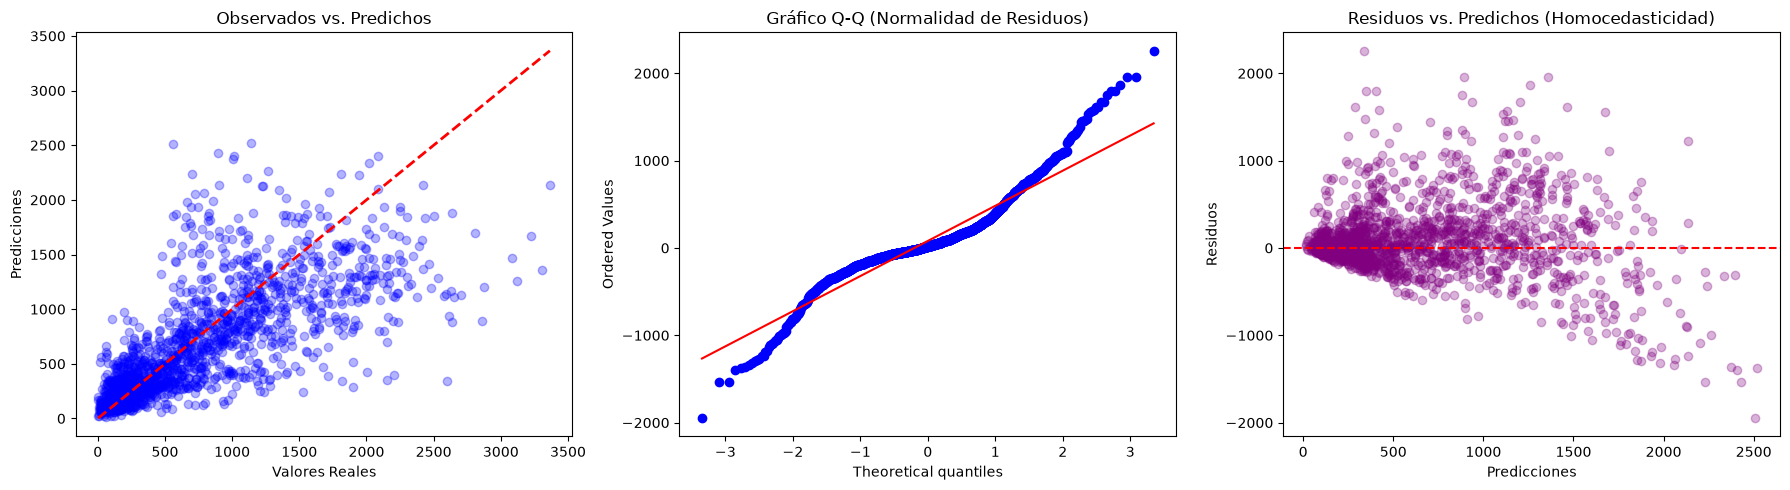

In [169]:
# Cálculo de residuos en la escala real
residuos = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A) Observados vs. Predichos (Línea de Regresión Ideal)
axes[0].scatter(y_test_real, y_pred_real, alpha=0.3, color='blue')
axes[0].plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--',
    lw=2,
)
axes[0].set_title('Observados vs. Predichos')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')

# B) Gráfico Q-Q Plot (Normalidad de Residuos)
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Gráfico Q-Q (Normalidad de Residuos)')

# C) Residuos vs. Predichos (Homocedasticidad)
axes[2].scatter(y_pred_real, residuos, alpha=0.3, color='purple')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs. Predichos (Homocedasticidad)')
axes[2].set_xlabel('Predicciones')
axes[2].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

**Análisis de Diagnóstico de Residuos**

1. ***Observados vs. Predichos:*** La línea roja discontinua representa la predicción perfecta. En valores bajos y medios de 0 a 1.000 bicicletas, los puntos azules se agrupan cerca de la línea. Sin embargo, a partir de las 1.500 bicicletas, los puntos se dispersan y caen mayoritariamente por debajo de la diagonal. Esto quiere decir que sí bien está pediciendo la parte inicial relativamente bien, las horas pico las está subestimando mayoritariamente, lo que coincide con la brecha observada previamente entre MAE y RMSE.

2. ***Gráfico Q-Q (Normalidad de los Residuos):*** Los puntos azules siguen la línea roja diagonal en el centro, pero se alejan en los extremos formando una ligera curva en "S" (hacia abajo en el extremo izquierdo y hacia arriba en el derecho).Esto indica que los residuos no siguen una distribución normal perfecta debido a eventos atípicos imprevistos que llevan la renta de bicicletas a valores muy bajos o muy altos, sin embargo notamos que el centro de la distribución se mantiene razonablemente alineado. Por qué los errores deberían tener una distribución normal


3. ***Residuos vs. Predichos (Homocedasticidad):*** Los residuos muestran una forma de "embudo" que se abre a medida que aumentan las predicciones en el eje horizontal.Esto quiere decir que en la regresión lineal existe heterocedasticidad (varianza no constante de los errores). Es decir la incertidumbre del modelo aumenta con la demanda. Por lo tanto, cuando el modelo predice un volumen bajo de bicicletas el margen de error es muy pequeño, pero cuando predice un volumen alto la dispersión de los errores se vuelve mucho más amplia, debido a las horas pico.

Por medio de estos gráficos, podemos observar que  el modelo es muy fiable para la rutina diaria, pero cuando ocurren eventos extremos (picos imprevistos de hora pico, tormentas o festivos), el modelo se queda corto o se pasa por un margen de alrededor de 1,000 a 1,200 bicicletas.

In [170]:
# Cálculo del VIF para cada variable explicativa
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

           Variable       VIF
1       Temperature  5.206948
11   Seasons_Winter  3.386838
2          Humidity  2.939553
10   Seasons_Summer  2.603292
5   Solar Radiation  1.989060
4        Visibility  1.720865
9    Seasons_Spring  1.708385
3        Wind speed  1.308611
7   Rainfall_binary  1.223844
8   Snowfall_binary  1.216201
0              Hour  1.215797
6           Holiday  1.021289


**Análisis del VIF (Factor de Inflación de la Varianza)**

El VIF mide cuánto se "infla" la varianza de un coeficiente de regresión debido a la colinealidad con las demás variables explicativas.

Valores de 1 se interpretan como ausencia de multicolinealidad, entre 1 y 5 con baja o moderada y mayor a 5 con alta.

En este caso podemos observar que la mayor parte de las variables explicativas presentan valores menores a 1, lo cual tiene sentido ya que eliminamos la multicolinealidad que existia con la variable Dew point temperature y además al usar drop_first=True en la codificación de las temporadas del año eliminando Otoño, evitamos valores altos de VIF. 

El VIF de Temperature es mayor a 5 por muy poco, lo cual se entiende con su relación a la radiación solar, sin embargo sigue estando dentro del límite inferior, razón por la cual la podemos mantener por el momento.

## 6. Series temporales

En esta sección aprovechando la información temporal, realizaremos el análisis de series temporales, en donde haremos lo siguiente:

- representar la serie temporal;
- analizar tendencia;
- estudiar la estacionalidad;
- aplicar medias móviles;
- comprobar la estacionariedad;
- construir un modelo ARIMA;
- evaluar la capacidad predictiva del modelo.

---

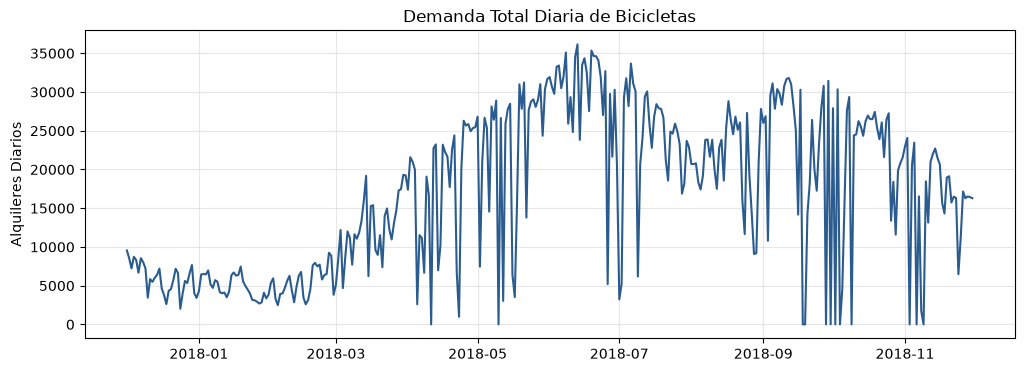

In [171]:
# Agrupación a nivel diario
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y') # Convertir a tipo datetime
# Agrupación por fecha y suma de la demanda diaria
df_daily = df.groupby('Date')['Rented Bike Count'].sum().reset_index()
# Establecer la columna 'Date' como índice del DataFrame
df_daily.set_index('Date', inplace=True)

# Representación gráfica de la serie
plt.figure(figsize=(12, 4))
plt.plot(df_daily.index, df_daily['Rented Bike Count'], color='#2b5c8f', linewidth=1.5)
plt.title('Demanda Total Diaria de Bicicletas')
plt.ylabel('Alquileres Diarios')
plt.grid(True, alpha=0.3)
plt.show()

**Análisis serie temporal anual**

Mínimo en Invierno (Dic 2017 - Feb 2018): Muestra el nivel más bajo del año, estabilizado entre 2,500 y 10,000 alquileres diarios por las bajas temperaturas.

Crecimiento en Primavera (Mar 2018 - May 2018): Presenta una pendiente positiva bien pronunciada, triplicando el alquiler de biciletas diario, causado por las mejores condiciones climáticas, lo cual concuerda con el alto coeficiente de la temperatura en el análisis.

Pico en Verano (Jun 2018 - Jul 2018): Alcanza el máximo histórico de la serie con picos cercanos a los 36,000 alquileres/día, que es cuando tenemos las temperaturas más altas y por lo tanto las condiciones climáticas más favorables para el uso de bicicletas.

Declive en Otoño (Ago 2018 - Nov 2018): Muestra una caída progresiva de la demanda conforme regresan las bajas temperaturas, lo que concuerda con el análisis bivariante que habíamos realizado anteriormente. 

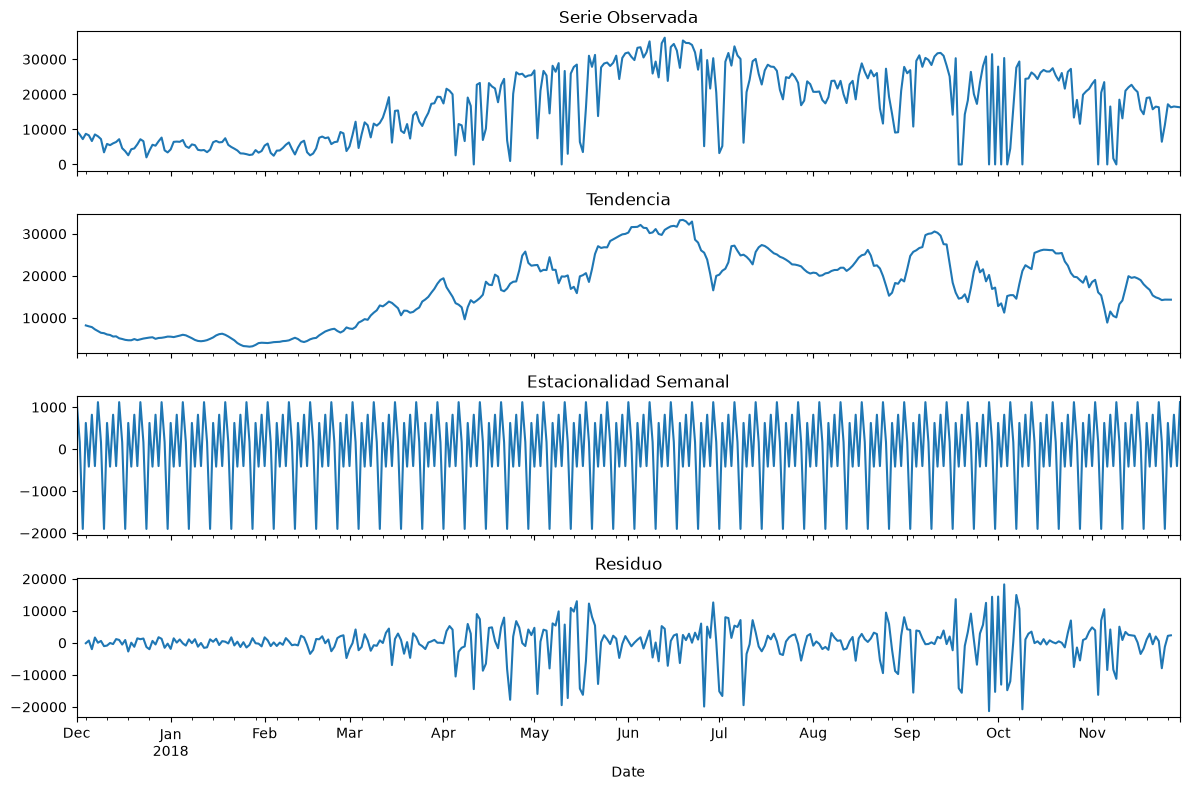

In [172]:
# Medias móviles
# Cálculo de medias móviles de 7 y 30 días para suavizar la serie temporal
df_daily['MA_7'] = df_daily['Rented Bike Count'].rolling(window=7).mean()

# Descomposición en Tendencia, Estacionalidad y Residuo (período semanal = 7)
decomp = seasonal_decompose(df_daily['Rented Bike Count'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
# Grafica de la serie observada
decomp.observed.plot(ax=axes[0], title='Serie Observada')
# Grafica de la tendencia, estacionalidad y residuo
decomp.trend.plot(ax=axes[1], title='Tendencia')
decomp.seasonal.plot(ax=axes[2], title='Estacionalidad Semanal')
decomp.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.show()

**Análisis de Tendencia**

El primer gráfico representa la serie observada con los datos reales para comparar los diferentes gráficos, en el análisis de tendencia se usan medias móviles centradas, las cuales toman el promedio de los 3 días antes, el día en sí y los 7 días posteriores, para de esta manera absorber el impacto de los días en que las rentas de bicicletas caen a cero repentinamente por condiciones climáticas o eventos temporales particulares. En est caso podemos observar con mayor facilidad el aumento de la renta de bicicletas en primavera y los picos máximos en verano, además del inicio del descenso en otoño y los valles mínimos en invierno.

**Estacionalidad semanal**

El gráfico de estacionalidad semanal se calcula tomando los valores del gráfico de la serie observada y restándole los valores de la gráfica de tendencia, luego con esos datos de alguna manera descentralizados se calcula el promedio histórico cada uno de los 7 días de la semana. Al final restamos el promedio global de todo el set de datos de los 365 días para que la sumatoria de los valores de la semana nos dé cero.

Entre el lunes y el viernes el gráfico sube por encima de cero más o menos en el valor de 1.000 lo que significa que en esos días en ciertas horas la demanda sube más de 1.000 bicicletas rentadas que la tendencia semanal normal. Mientras que los fines de semana que no son laborales, llega a presentar disminuciones de hasta 2.000 bicicletas rentandas, respecto a la tendencia semanal.

**Residuo**

El residuo es la diferencia entre lo que realmente ocurrió y lo que se consideraba un día 'normal' según el mes del año (tendencia) y el día de la semana (estacionalidad semanal).

Invierno (Diciembre - Febrero): Los residuos son muy estables y oscilan muy poco, esto tiene sentido, ya que las condiciones climáticas adversas como la baja temperatura y la nieve hacen que las personas no usen por completo el servicio de bicicletas.

Primavera, Verano u Otoño (Marzo - Noviembre): La dispersión del residuo es grande y oscila con frecuencia entre 10.000 y 20.000 bicicletas, mostrando que la volatilidad de la demanda aumenta drásticamente cuando el clima se vuelve cálido. Dado que aquí sí se ve la dinámica normal de las horas pico y los eventos climáticos esporádicos. 

In [173]:
# Prueba de estacionariedad con ADF (Augmented Dickey-Fuller Test)
adf_result = adfuller(df_daily['Rented Bike Count'])
print(f"Estadístico ADF: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] > 0.05:
    print("La serie NO es estacionaria. Se requiere aplicar diferenciación (d=1).")
else:
    print("La serie ES estacionaria.")

Estadístico ADF: -2.5966
p-value: 0.0937
La serie NO es estacionaria. Se requiere aplicar diferenciación (d=1).


C:\Users\maik_\AppData\Local\Temp\ipykernel_29656\321341726.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df_daily['Rented Bike Count'])


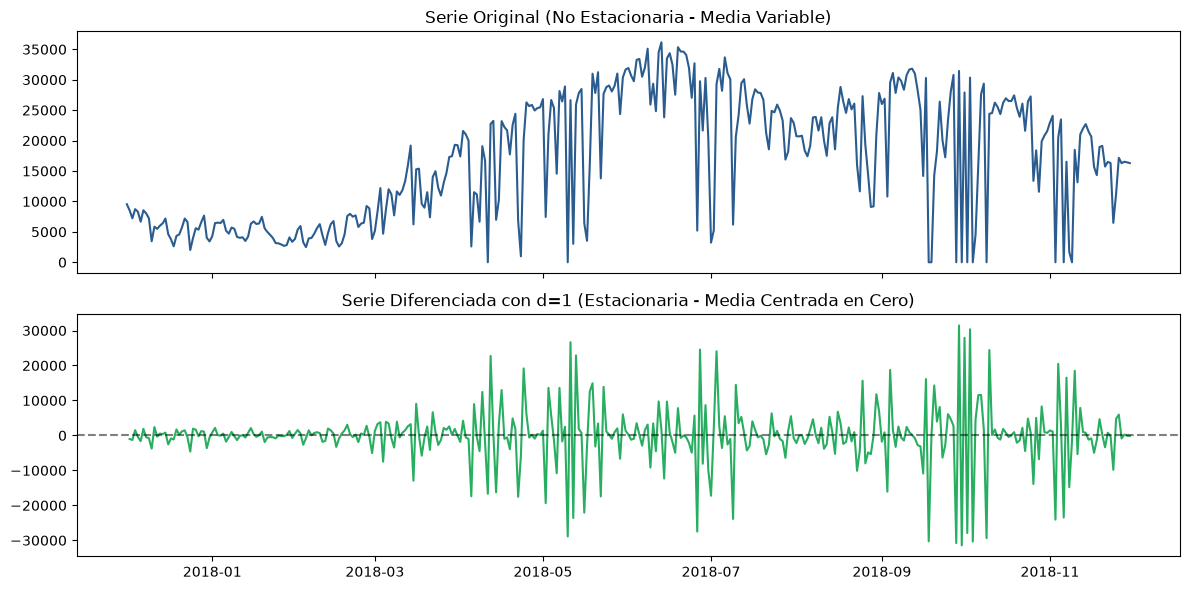

In [174]:
# Aplicar la primera diferencia (d=1)
df_daily['Diff_1'] = df_daily['Rented Bike Count'].diff()

# Graficar Serie Original vs Diferenciada
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df_daily['Rented Bike Count'], color='#2b5c8f')
axes[0].set_title('Serie Original (No Estacionaria - Media Variable)')

axes[1].plot(df_daily['Diff_1'], color='#27ae60')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Serie Diferenciada con d=1 (Estacionaria - Media Centrada en Cero)')
plt.tight_layout()
plt.show()

**Análisis estacionariedad con ADF (Augmented Dickey-Fuller Test)**

La prueba de Dickey-Fuller Aumentada (ADF) es un test estadístico que nos sirve para verificar si la serie de datos es estacionaria o no. una serie es estacionaria si sus propiedades estadísticas (como la media y la variabilidad) se mantienen constantes a lo largo del tiempo, sin tendencias que suban o bajen progresivamente. (Gemini, 2026)

**Análisis Numérico de la Prueba ADF**

El p-valor (0.0937): La regla establece que para considerar una serie estable (estacionaria), este número debe estar por debajo de 0.05 (un 5%). Como nuestro resultado fue 0.0937, la prueba confirma que la demanda no se mantiene en un nivel fijo a lo largo del año, lo cual se confirma gráficamente.

Diagnóstico real: Muestra que no podemos evaluar la demanda de la misma manera todo el tiempo, ya que el volumen cambia drásticamente entre un día de una temporada y otra.

Diferenciación d=1: Para estabilizar el modelo. En lugar de pedirle predecir "cuántas bicicletas se alquilarán hoy en total", le pedimos predecir "el cambio de alquileres de hoy respecto al día anterior", lo cual consiste simplemente en restar a cada valor de la serie el valor del día inmediatamente anterior, de esta manera se genera una media de referencia en el cero y no múltiples medias por temporada como estaba antes.

**Análisis Visual: Serie Original vs. Diferenciada**

Esta transformación deja al descubierto los eventos atípicos. En invierno las variaciones de un día a otro son pequeñas dado lo uniforme de las condiciones climáticas, lo que es el condicionante para que no usen mucho las bicicletas. Entre mayo y noviembre se observan desplomes muy grandes que llegan hasta los -30,000. Esos valles profundos corresponden a los días en los que se presentaban condiciones climáticas adversas o situaciones ajenas a la operación.

Modelar y mejorar el tratamiento de la estacionalidad sirve para que el modelo aprenda los patrones repetitivos del calendario y pueda anticipar picos o caídas habituales sin confundirlos con fluctuaciones aleatorias o cambios de tendencia del negocio. (Gemini, 2026)


In [175]:
# Parámetro de evaluación (Días a predecir al final del histórico)
HORIZONTE_TEST = 30

# División temporal de la serie (Train: Histórico / Test: Últimos 30 días)
train = df_daily['Rented Bike Count'].iloc[:-HORIZONTE_TEST]
test = df_daily['Rented Bike Count'].iloc[-HORIZONTE_TEST:]

# Configuración y entrenamiento del modelo SARIMAX
# (order: p=1 autoregresivo, d=1 diferencia, q=1 media móvil)
# (seasonal_order: P=1, D=1, Q=1 con ciclo semanal s=7)
modelo_sarimax = SARIMAX(
    train, 
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 7)
)
resultado_fit = modelo_sarimax.fit(disp=False)

# Generación de predicciones directas para el horizonte de test
predicciones = resultado_fit.forecast(steps=HORIZONTE_TEST)

# Cálculo de métricas de desempeño
rmse = np.sqrt(mean_squared_error(test, predicciones))
mae = mean_absolute_error(test, predicciones)

# Presentación gráfica de resultados en consola
print(f"=== Evaluación del Modelo SARIMAX ({HORIZONTE_TEST} días) ===")
print(f"MAE  (Error Medio Absoluto): {mae:.2f} bicicletas/día")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.2f} bicicletas/día")

C:\Users\maik_\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\maik_\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


=== Evaluación del Modelo SARIMAX (30 días) ===
MAE  (Error Medio Absoluto): 7053.04 bicicletas/día
RMSE (Raíz del Error Cuadrático): 9673.32 bicicletas/día


**Evaluación del Modelo SARIMAX Baseline (30 Días de Prueba)**

* **MAE (Error Medio Absoluto — 7,053.04 bicicletas/día):** En promedio, las predicciones del modelo se alejan en unas 7,053 bicicletas por día del valor real. 

* **RMSE (Raíz del Error Cuadrático Medio — 9,673.32 bicicletas/día):** Al penalizar con mayor severidad los fallos más grandes, un RMSE casi 2.600 unidades superior al MAE evidencia que los errores no están distribuidos de forma uniforme. Existen días puntuales en la ventana con valores muy grandes o muy bajos que afectan el indicador.

* **Ausencia de contexto meteorológico:** Esta versión baseline de SARIMAX opera como una serie de tiempo univariada, basándose únicamente en el histórico de demanda y en la estacionalidad semanal. Por lo tanto, es incapaz de anticipar variaciones originadas por factores externos al calendario, como episodios imprevistos de precipitaciones intensas o temperaturas extremas.

* **Justificación de la Inclusión de Variables Explicativas en la Regresión Lineal:** Mientras que el modelo SARIMAX baseline univariado registra un Error Absoluto Medio (MAE) de 7,053.04 bicicletas/día considerando únicamente la secuencia temporal del calendario, la Regresión Lineal multivariada obtiene un MAE de 268.88 bicicletas/hora. Al multiplicar este valor por 24 para dejarlo en días también obtenemos 6.453 bicis/día, el modelo de regresión logra una reducción del error del 8.5%, superando en precisión al SARIMAX por aproximadamente 600 bicicletas diarias.

## 7. Modelado probabilístico

Ahora diseñaremos una red bayesiana relacionada con el problema.

para este análisis usaremos las siguientes variables:

- lluvia;
- temperatura;
- estación;
- demanda elevada.

---

In [176]:
# ==============================================================================
# DEFINICIÓN DE UMBRALES DE NEGOCIO Y AGREGACIÓN DIARIA
# ==============================================================================
UMBRAL_DEMANDA = 20000  # Bicicletas al día (>20k = Demanda Elevada)
UMBRAL_TEMP = 15.0  # Grados Celsius (>15°C = Temp Alta)

# Agrupamos los registros horarios a nivel diario
df_diario = (
    df.groupby("Date")
    .agg(
        {
            "Rented Bike Count": "sum",
            "Temperature": "mean",
            "Rainfall": "sum",
            "Seasons": "first",
        }
    )
    .reset_index()
)

# ==============================================================================
# TRANSFORMACIÓN DE DATOS REALES A VARIABLES DISCRETAS (0 y 1)
# ==============================================================================
df_bayes = pd.DataFrame()

# Estacion: 1 = Primavera/Verano (Cálido), 0 = Otoño/Invierno (Frío)
df_bayes["Estacion"] = (
    df_diario["Seasons"].isin(["Spring", "Summer"])
).astype(int)

# Temperatura: 1 = > 15°C (Alta), 0 = <= 15°C (Baja)
df_bayes["Temperatura"] = (
    df_diario["Temperature"] > UMBRAL_TEMP
).astype(int)

# Lluvia: 1 = > 0 mm (Sí), 0 = 0 mm (No)
df_bayes["Lluvia"] = (df_diario["Rainfall"] > 0).astype(int)

# Demanda_Elevada: 1 = > 20,000 bicis/día (Elevada), 0 = <= 20,000 bicis/día (Normal)
df_bayes["Demanda_Elevada"] = (
    df_diario["Rented Bike Count"] > UMBRAL_DEMANDA
).astype(int)

# ==============================================================================
# CONSTRUCCIÓN DEL DAG Y APRENDIZAJE AUTOMÁTICO DE CPTs (Frecuencias)
# ==============================================================================
modelo = DiscreteBayesianNetwork(
    [
        ("Estacion", "Temperatura"),
        ("Estacion", "Lluvia"),
        ("Temperatura", "Demanda_Elevada"),
        ("Lluvia", "Demanda_Elevada"),
    ]
)

# En DiscreteBayesianNetwork, fit() usa automáticamente Máxima Verosimilitud (DiscreteMLE)
modelo.fit(df_bayes)

# Validar consistencia matemática
assert modelo.check_model()

# ==============================================================================
# IMPRESIÓN DE CPTs GENERADAS Y MOTOR DE INFERENCIA
# ==============================================================================
for cpd in modelo.get_cpds():
    print(f"\n--- Tabla CPT de la variable: {cpd.variable} ---")
    print(cpd)

inferencia = VariableElimination(modelo)


--- Tabla CPT de la variable: Estacion ---
+-------------+---------+
| Estacion(0) | 0.49589 |
+-------------+---------+
| Estacion(1) | 0.50411 |
+-------------+---------+

--- Tabla CPT de la variable: Temperatura ---
+----------------+---------------------+---------------------+
| Estacion       | Estacion(0)         | Estacion(1)         |
+----------------+---------------------+---------------------+
| Temperatura(0) | 0.7900552486187845  | 0.27717391304347827 |
+----------------+---------------------+---------------------+
| Temperatura(1) | 0.20994475138121546 | 0.7228260869565217  |
+----------------+---------------------+---------------------+

--- Tabla CPT de la variable: Lluvia ---
+-----------+--------------------+--------------------+
| Estacion  | Estacion(0)        | Estacion(1)        |
+-----------+--------------------+--------------------+
| Lluvia(0) | 0.7845303867403315 | 0.657608695652174  |
+-----------+--------------------+--------------------+
| Lluvia(1) | 0.

In [177]:
# Mejoramos la visualización de la última tabla
cpd = modelo.get_cpds("Demanda_Elevada")

df_demanda = pd.DataFrame(
    cpd.get_values(),
    index=["Demanda Normal (0)", "Demanda Elevada (1)"],
    columns=[
        "L=0, T=0 (Seco / Frío)",
        "L=0, T=1 (Seco / Cálido)",
        "L=1, T=0 (Lluvia / Frío)",
        "L=1, T=1 (Lluvia / Cálido)",
    ],
)

print(df_demanda)

                     L=0, T=0 (Seco / Frío)  L=0, T=1 (Seco / Cálido)  L=1, T=0 (Lluvia / Frío)  L=1, T=1 (Lluvia / Cálido)
Demanda Normal (0)                 0.785235                  0.114035                  0.911111                    0.508772
Demanda Elevada (1)                0.214765                  0.885965                  0.088889                    0.491228


**Explicación configuración Red Bayesiana**

Estructuramos un Grafo Dirigido Acíclico (DAG) donde la variable raíz Estación influye en la Temperatura y la Lluvia, las cuales se analizan juntas para determinar conjuntamente la probabilidad de registrar una Demanda Elevada de bicicletas. Para alimentar la red con la información histórica del proyecto, discretizamos las variables continuas en binarios (0, 1) y aplicando umbrales de negocio y criterios estadísticos concretos:

Estación: 1 = Cálida (Primavera/Verano), 0 = Fría (Otoño/Invierno).

Temperatura: 1 = Alta (> 15C), 0 = Baja (<= 15C).

Lluvia: 1 = Presencia de precipitación, 0 = Día seco (0mm).

Demanda Elevada: 1 = Pico de operación (> 20,000$ bicicletas/día), 0 = Operación normal (<= 20,000 bicicletas/día).

las Tablas de Probabilidad Condicional (CPT) se calcularon automáticamente desde el dataset mediante el estimador de Máxima Verosimilitud (DiscreteMLE), de esta manera calculamos la probabilidad condicional a partir de las frecuencias relativas de nuestro dataset.

En la tabla relacionada con la probabilidad de demanda en relación a la lluvia y la temperatura, podemos observar como al tener condiciones de buena temperatura y un ambiente sin lluvia, es donde existe mayor probabilidad de tener mayores pico de renta de bicicletas, y concordando con los análisis previos, las peores condiciones serían temperaturas bajas y presencia de lluvias.

In [178]:
# ==============================================================================
# EJECUCIÓN DE ESCENARIOS
# ==============================================================================

print("=== RESULTADOS DEL MODELADO PROBABILÍSTICO ===\n")

# Pregunta: ¿Cuál es la probabilidad general de alta demanda sin mirar el clima?
# Método: Calcula P(Demanda_Elevada = 1) promediando todo el histórico probabilístico.
res_0 = inferencia.query(variables=['Demanda_Elevada'])
p_d1_base = res_0.values[1]
print(f"Escenario 0 (Base General):")
print(f"P(Demanda Elevada) = {p_d1_base:.4f} ({p_d1_base * 100:.1f}%)\n")

# Escenario 1: Día Ideal Temperatura alta (T=1) y ausencia de lluvia (L=0).
res_1 = inferencia.query(variables=['Demanda_Elevada'], evidence={'Temperatura': 1, 'Lluvia': 0})
p_d1_ideal = res_1.values[1]
print(f"Escenario 1 (Día Ideal - Alta Temp, Sin Lluvia):")
print(f"P(Demanda Elevada | T=1, L=0) = {p_d1_ideal:.4f} ({p_d1_ideal * 100:.1f}%)\n")

# Escenario 2: Día Adverso Temperatura baja (T=0) y presencia de lluvia (L=1).
res_2 = inferencia.query(variables=['Demanda_Elevada'], evidence={'Temperatura': 0, 'Lluvia': 1})
p_d1_adverso = res_2.values[1]
print(f"Escenario 2 (Día Adverso - Baja Temp, Con Lluvia):")
print(f"P(Demanda Elevada | T=0, L=1) = {p_d1_adverso:.4f} ({p_d1_adverso * 100:.1f}%)\n")

# Escenario donde la demanda del día fue alta (Demanda_Elevada = 1)
# Invirtiendo las flechas del grafo, ¿cuál es la probabilidad de que haya llovido?
# Método: Aplica el Teorema de Bayes para calcular P(Lluvia = 1 | Demanda_Elevada = 1)
res_3 = inferencia.query(variables=['Lluvia'], evidence={'Demanda_Elevada': 1})
p_l1_diag = res_3.values[1]
print(f"Escenario 3 (Diagnóstico Inverso - Dado que hubo Alta Demanda):")
print(f"P(Lluvia = Sí | Demanda=1) = {p_l1_diag:.4f} ({p_l1_diag * 100:.2f}%)")

=== RESULTADOS DEL MODELADO PROBABILÍSTICO ===

Escenario 0 (Base General):
P(Demanda Elevada) = 0.4545 (45.4%)

Escenario 1 (Día Ideal - Alta Temp, Sin Lluvia):
P(Demanda Elevada | T=1, L=0) = 0.8860 (88.6%)

Escenario 2 (Día Adverso - Baja Temp, Con Lluvia):
P(Demanda Elevada | T=0, L=1) = 0.0889 (8.9%)

Escenario 3 (Diagnóstico Inverso - Dado que hubo Alta Demanda):
P(Lluvia = Sí | Demanda=1) = 0.1850 (18.50%)


**Análisis de Resultados Red Bayesiana:**

Análisis de los Escenarios

* **Escenario 0 (Base General — 45.4%):** Sin mayor información que las probabilidades calculadas al inicio, la probabilidad de que el sistema registre un día de demanda elevada ($> 20,000$ bicicletas) es del 45.4% (aproximadamente 166 días al año). Que se calcula ...


* **Escenario 1 (Día Ideal — 88.6%):** En días cálidos y secos sin lluvia, la probabilidad de alta demanda casi se duplica respecto a la base, alcanzando un 88.6%. Representa el escenario en donde se debería tener mayor disponibilidad.

* **Escenario 2 (Día Adverso — 8.9%):** En días frios con lluvias podríamos inferir que muy pocas personas quisieran usar una bici, sin embargo con el modelo de probabilidad sabemos que el servicio colapsaría teniendo solo un 8,9% de que las personas lo usen. Esto es importante, porque podríamos generar estrategias para realizar los mantenimientos en estas temporadas del año, ya que generalmente se presentaran estas condiciones.

* **Escenario 3 (Diagnóstico Inverso — 18.50%):** Al observar un día de alta demanda ya registrado, la probabilidad de que haya llovido cae al 18.50%. Este razonamiento bayesiano demuestra que un volumen elevado de viajes descarta de manera efectiva la presencia de mal clima en el sistema.

## 8. Lógica difusa

Ahora procederemos en diseñar un sistema de inferencia difusa relacionado con la demanda de bicicletas. 

Con el objetivo de clasificar el riesgo de saturación del sistema:

- Riesgo bajo, medio y alto de saturación del sistema.

Además definiremos las funciones de pertenencia que usaremos en el análisis para comprender la elección.

---

C:\Users\maik_\AppData\Roaming\Python\Python313\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


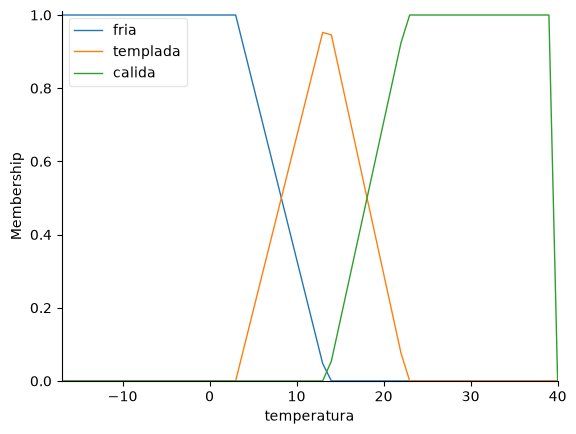

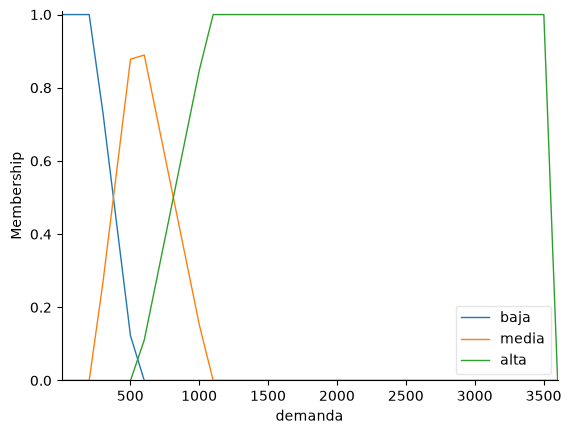

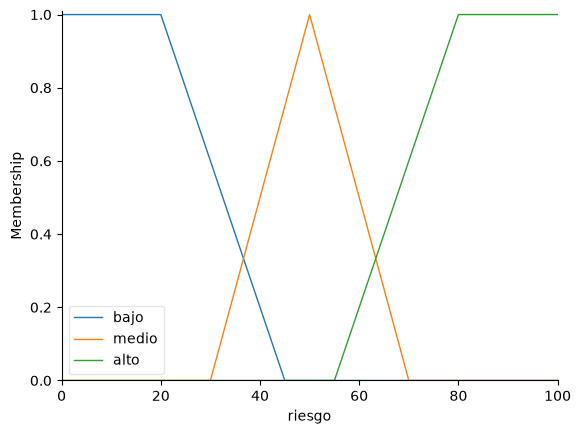

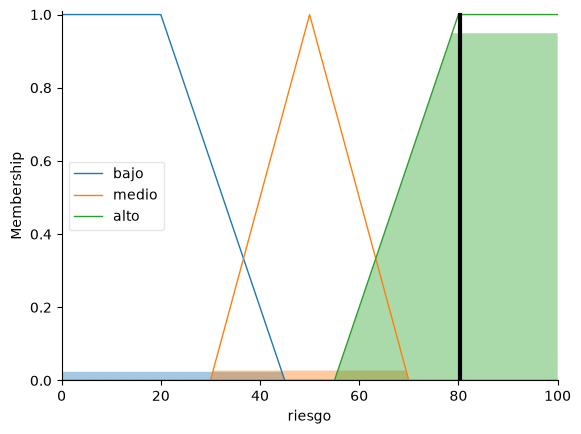

ENTRADAS : Temperatura = 13.5°C (P50) | Demanda = 1,084 bicis/día (P75)
RESULTADO: Riesgo de Saturación Calculado = 80.41%


In [179]:
# Agrupamos date y calculamos la suma de la demanda diaria y la media de la temperatura
grupo_fecha = 'Date' if 'Date' in df_prep.columns else df_prep.index

df_daily = df_prep.groupby(grupo_fecha).agg({
    'Rented Bike Count': 'sum',
    'Temperature': 'mean'
})

# Extraemos límites y percentiles (P25, P50, P75)
t_min, t_max = int(df_daily['Temperature'].min()), int(df_daily['Temperature'].max())
d_min, d_max = int(df_daily['Rented Bike Count'].min()), int(df_daily['Rented Bike Count'].max())
tp25, tp50, tp75 = np.percentile(df_daily['Temperature'], [25, 50, 75])
dp25, dp50, dp75 = np.percentile(df_daily['Rented Bike Count'], [25, 50, 75])

# Universos de Discurso, es decir que valor e 0 a 100%
# se añaden algunos valores al límite superior para que las funciones de pertenencia trapezoidales no se corten abruptamente
# Temperatura: rango de 0 a 40°C, con pasos de 1°C
temperatura = ctrl.Antecedent(np.arange(t_min, t_max + 2, 1), 'temperatura')
# Demanda: rango de 0 a 30,000 bicis/día, con pasos de 100 bicis/día
demanda = ctrl.Antecedent(np.arange(d_min, d_max + 100, 100), 'demanda')
# Riesgo: rango de 0 a 100%, con pasos de 1%
riesgo = ctrl.Consequent(np.arange(0, 101, 1), 'riesgo')

# Funciones de Pertenencia
# Traza las funciones de pertenencia para cada variable difusa
# Para saber en qué porcentaje pertenece un valor a cada categoría (fría, templada, cálida) para temperatura
temperatura['fria'] = fuzz.trapmf(temperatura.universe, [t_min, t_min, tp25, tp50])
temperatura['templada'] = fuzz.trimf(temperatura.universe, [tp25, tp50, tp75])
temperatura['calida'] = fuzz.trapmf(temperatura.universe, [tp50, tp75, t_max, t_max])
# Para saber en qué porcentaje pertenece un valor a cada categoría (baja, media, alta) para demanda
demanda['baja'] = fuzz.trapmf(demanda.universe, [d_min, d_min, dp25, dp50])
demanda['media'] = fuzz.trimf(demanda.universe, [dp25, dp50, dp75])
demanda['alta'] = fuzz.trapmf(demanda.universe, [dp50, dp75, d_max, d_max])
# Para saber en qué porcentaje pertenece un valor a cada categoría (bajo, medio, alto) para riesgo
riesgo['bajo'] = fuzz.trapmf(riesgo.universe, [0, 0, 20, 45])
riesgo['medio'] = fuzz.trimf(riesgo.universe, [30, 50, 70])
riesgo['alto'] = fuzz.trapmf(riesgo.universe, [55, 80, 100, 100])

# Graficar las funciones de pertenencia de las variables
temperatura.view()
demanda.view()
riesgo.view()


# Reglas e Inferencia
# Definimos el motor de razonamiento difuso con reglas de inferencia
reglas = [
    ctrl.Rule(demanda['alta'] & (temperatura['calida'] | temperatura['templada']), riesgo['alto']),
    ctrl.Rule(demanda['alta'] & temperatura['fria'], riesgo['medio']),
    ctrl.Rule(demanda['media'] & (temperatura['calida'] | temperatura['templada']), riesgo['medio']),
    ctrl.Rule(demanda['media'] & temperatura['fria'], riesgo['bajo']),
    ctrl.Rule(demanda['baja'], riesgo['bajo'])
]

simulador = ctrl.ControlSystemSimulation(ctrl.ControlSystem(reglas))

# Prueba evaluando con mediana de temperatura y percentil 75 de demanda
simulador.input['temperatura'] = tp50
simulador.input['demanda'] = dp75
simulador.compute()

# Graficar la salida de la simulación marcando el centroide (80.41%)
riesgo.view(sim=simulador)

# Graficar los graficos de pertenencia y la salida difusa
plt.show()

print(f"ENTRADAS : Temperatura = {tp50:.1f}°C (P50) | Demanda = {int(dp75):,} bicis/día (P75)")
print(f"RESULTADO: Riesgo de Saturación Calculado = {simulador.output['riesgo']:.2f}%")

**## **Sistema de Inferencia Difusa: Evaluación del Riesgo de renta**

Se diseñó un Sistema de Inferencia Difusa (Mamdani) para transformar variables cuantitativas de entorno en un indicador cualitativo y cuantitativo de **Riesgo de Saturación Operativa** en la red de bicicletas públicas.

**Variables usadas:**
  * **Temperatura (C):** Agrupada por media diaria. Particionada mediante percentiles (P25, P50, P75) en los conjuntos difusos: Fría, Templada y Cálida.

  * **Demanda (Bicicletas/día):** Agrupada por suma diaria. Dividida mediante percentiles para clasificarlo como: Baja, Media y Alta.

* **Variable de Salida:**
  * **Riesgo (%):** Escala de 0% a 100%, se clasifica en los conjuntos Bajo (0-45%), Medio (30-70%) y Alto (55-100%).

**Interpretación de resultados**

Se simuló un día típico de alta afluencia en condiciones meteorológicas templadas/promedio, en este caso 13.5°C con una demanda de 1,084 bicis/día, es decir temperatura Templada y demanda Alta. Obteniendo un nivel de riesgo del 80.41%

Para entender el resultado es necesario realizar el paso a paso que el algoritmo realiza para la clasificación.

* Difuzificación: Toma los 13.5°C y 1,084 bicis/hora y calcula qué tanto pertenecen a cada conjunto (ej. 80% Templada y 20% Cálida)

* Inferencia: Evalua las reglas de inferencia, según la clase en la que caen, evaluando la fuerza con la que cumplen la condición

* Agregación: Junta las salidas y su fuerza (niveles de riesgo) y forma un único polígono combinado

* Desdifuzificación (Centroide): Calcula el centro de gravedad numérico de ese polígono final, así es como obtenemos el 80,41%



**Interpretación de los gráficos**
Líneas en las entradas: En el gráfico de temperatura la línea de 13.5C toca la curva templada cerca del 100% y en el de demanda en 1,084 bicis (toca la curva alta cerca del 95%).

Luego el sistema toma el menor que es 95% para el alto del polígono que aparece en el último gráfico. En las curvas azul y naranja observamos una pequeña linea que es donde se activaron con los valores de temperatura y demanda que le dimos. Finalmente el centro del polígono será el valor de 80,41%.

## 9. Clustering

Ahora vamos a aplicar técnicas de segmentación utilizando:

- K-Means.
- Fuzzy C-Means.

En donde vamos a comparar ambos algoritmos mediante:

- centroides;
- pertenencias difusas;
- casos ambiguos;
- entropía de pertenencia;
- coeficiente FPC.

Al final vamos a interpretar los perfiles obtenidos.

---

In [180]:
# Preparación de variables clave y Escalamiento de Datos
X = df_daily[['Temperature', 'Rented Bike Count']].values
# Estandarización Media 0 y Desviación 1 para evitar que la escala 
# de la demanda domine sobre la temperatura en el cálculo de distancias
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3  # Definimos 3 clusters (Valle, Medio, Pico)

# ----------------------------------------------------------------------
# Algoritmo K-Means (Asignación Rígida)
# K-Means: Agrupamiento Rígido (Cada día pertenece a UN solo grupo al 100%)
# ----------------------------------------------------------------------
# Instanciamos K-Means con asignación binaria rígida (pertenencia 0 o 1)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Desescalamos los centroides a sus unidades originales (°C y bicis/día)
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# ----------------------------------------------------------------------
# Algoritmo Fuzzy C-Means (Asignación Difusa)
# Un día puede repartirse entre varios grupos
# ----------------------------------------------------------------------
# skfuzzy.cmeans requiere la matriz traspuesta: (N_features, N_muestras)
cntr_scaled, u, _, _, _, _, fpc = fuzz.cmeans(
    X_scaled.T, # Generamos matriz traspuesta para que quede en formato (variables, muestras)
    c=k, # Número de clusters
    m=2.0, # Ponderador difuso, entre mayor, más difuso será el agrupamiento
    error=0.005, # Criterio de convergencia (error máximo permitido), sí es menor
    # a 0.005, el algoritmo se detiene y devuelve los resultados
    maxiter=1000, # Número máximo de iteraciones permitidas
    init=None,  # Inicialización aleatoria de centroides (None = aleatorio)
    seed=42 # Semilla para reproducibilidad de resultados
)

# Convertimos los centroides a la escala real (°C y bicis/día)
cmeans_centers = scaler.inverse_transform(cntr_scaled)

# Obtenemos la tabla de porcentajes de pertenencia por día
u_matrix = u.T 
# Identificamos el grupo con el porcentaje más alto
cmeans_labels = np.argmax(u_matrix, axis=1)
# Guardamos ese porcentaje más alto
max_membership = np.max(u_matrix, axis=1)

# ----------------------------------------------------------------------
# Cálculo de Métricas Comparativas
# ----------------------------------------------------------------------
# Entropía de Pertenencia (Incertidumbre global)
# Entropía: Mide la duda global del modelo (A mayor valor, más confusión entre grupos)
eps = 1e-10
entropy = -np.mean(np.sum(u_matrix * np.log(u_matrix + eps), axis=1))

# Casos Ambiguos: días donde la pertenencia máxima no alcanza el 50%
umbral_ambiguedad = 0.50 
# sí es menor a 50% se flagea como ambiguo para CMeans
casos_ambiguos = np.where(max_membership < umbral_ambiguedad)[0] 

# ----------------------------------------------------------------------
# Guardar los resultados ordenados en una tabla final
# ----------------------------------------------------------------------
df_clustering = df_daily.copy()
df_clustering['KMeans_Cluster'] = kmeans_labels
df_clustering['CMeans_Cluster'] = cmeans_labels
df_clustering['CMeans_Max_Pertenencia'] = max_membership
df_clustering['Es_Ambiguo'] = max_membership < umbral_ambiguedad

In [181]:
print("=== 1. COMPARACIÓN DIRECTA: K-MEANS vs C-MEANS (Primeros 10 Días) ===")
cols_comparativa = [
    'Temperature', 
    'Rented Bike Count', 
    'KMeans_Cluster', 
    'CMeans_Cluster', 
    'CMeans_Max_Pertenencia', 
    'Es_Ambiguo'
]
print(df_clustering[cols_comparativa].head(10))

print("\n=== 2. DESGLOSE DE PERTENENCIA DIFUSA EN C-MEANS (Primeros 5 Días) ===")
cols_probabilidades = ['u_Valle_Baja', 'u_Medio_Transicion', 'u_Pico_Alta']
df_pertenencias = pd.DataFrame(
    u_matrix, 
    columns=cols_probabilidades, 
    index=df_daily.index
)
print((df_pertenencias.head(10) * 100).round(1).astype(str) + '%')

=== 1. COMPARACIÓN DIRECTA: K-MEANS vs C-MEANS (Primeros 10 Días) ===
   Temperature  Rented Bike Count  KMeans_Cluster  CMeans_Cluster  CMeans_Max_Pertenencia  Es_Ambiguo
0         -5.2                254               2               1                0.940206       False
1         -5.5                204               2               1                0.934709       False
2         -6.0                173               2               1                0.924855       False
3         -6.2                107               2               1                0.915412       False
4         -6.0                 78               2               1                0.914468       False
5         -6.4                100               2               1                0.911451       False
6         -6.6                181               2               1                0.915291       False
7         -7.4                460               2               1                0.873441       False
8         -7

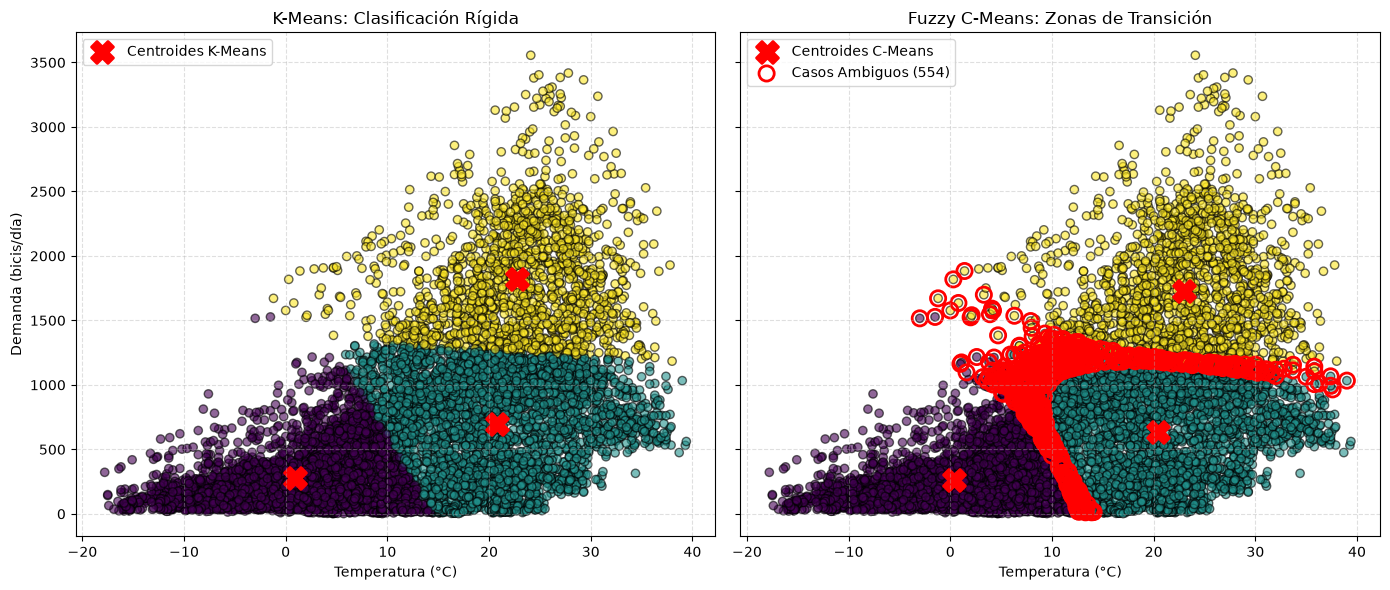

In [182]:
# Reordenar clusters por nivel de demanda (0: Baja, 1: Media, 2: Alta)
km_order = np.argsort(kmeans_centers[:, 1])
cm_order = np.argsort(cmeans_centers[:, 1])

# Reasignar etiquetas de clusters para que coincidan con el orden de demanda
c_km = df_clustering['KMeans_Cluster'].map({old: new for new, old in enumerate(km_order)})
c_cm = df_clustering['CMeans_Cluster'].map({old: new for new, old in enumerate(cm_order)})

# Reordenar los centroides para que coincidan con el orden de demanda
km_centers_sorted = kmeans_centers[km_order]
cm_centers_sorted = cmeans_centers[cm_order]

# Gráficos comparativos de K-Means y Fuzzy C-Means
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Configuración de los gráficos
plots_config = [
    (axes[0], c_km, km_centers_sorted, "K-Means: Clasificación Rígida", "Centroides K-Means"),
    (axes[1], c_cm, cm_centers_sorted, "Fuzzy C-Means: Zonas de Transición", "Centroides C-Means")
]

# Graficar los clusters y centroides
for ax, clusters, centers, title, label in plots_config:
    ax.scatter(df_clustering['Temperature'], df_clustering['Rented Bike Count'], 
               c=clusters, cmap='viridis', alpha=0.6, edgecolor='k')
    ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=250, 
               linewidths=2, label=label)
    ax.set_title(title)
    ax.set_xlabel("Temperatura (°C)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

axes[0].set_ylabel("Demanda (bicis/día)")

# Resaltar casos ambiguos exclusivamente en C-Means
ambiguos = df_clustering[df_clustering['Es_Ambiguo']]
axes[1].scatter(ambiguos['Temperature'], ambiguos['Rented Bike Count'], 
                facecolors='none', edgecolors='red', s=120, linewidth=2, 
                label=f'Casos Ambiguos ({len(ambiguos)})')
axes[1].legend()

# Ajuste de diseño y visualización
plt.tight_layout()
plt.show()

                    K-Means  C-Means  Ambiguos (<50%)
Valle (Baja)           3584     3481              132
Medio (Transición)     3301     3200              288
Pico (Alta)            1580     1784              134


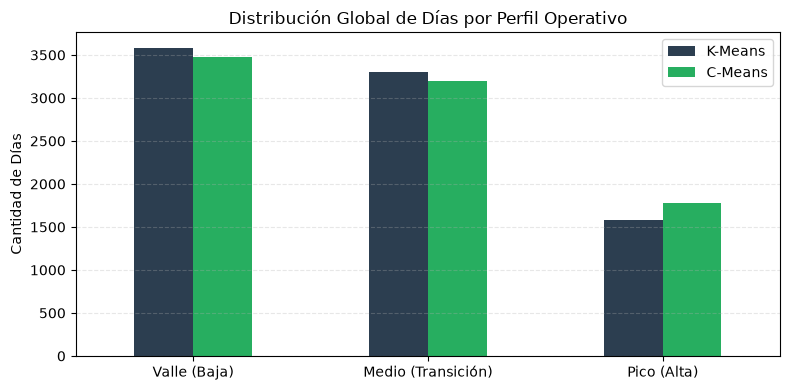

In [183]:
# Mapear nombres según el orden de demanda
nombres = ['Valle (Baja)', 'Medio (Transición)', 'Pico (Alta)']
df_clustering['KM_Perfil'] = df_clustering['KMeans_Cluster'].map({old: nombres[new] for new, old in enumerate(km_order)})
df_clustering['CM_Perfil'] = df_clustering['CMeans_Cluster'].map({old: nombres[new] for new, old in enumerate(cm_order)})

# Crear tabla resumen
resumen_global = pd.DataFrame({
    'K-Means': df_clustering['KM_Perfil'].value_counts(),
    'C-Means': df_clustering['CM_Perfil'].value_counts(),
    'Ambiguos (<50%)': df_clustering[df_clustering['Es_Ambiguo']]['CM_Perfil'].value_counts()
}).reindex(nombres).fillna(0).astype(int)

print(resumen_global)

# Gráfico de barras
resumen_global[['K-Means', 'C-Means']].plot(kind='bar', figsize=(8, 4), rot=0, color=['#2c3e50', '#27ae60'])
plt.title("Distribución Global de Días por Perfil Operativo")
plt.ylabel("Cantidad de Días")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [184]:
# Conteo de días ambiguos
total_ambiguos = df_clustering['Es_Ambiguo'].sum()

# Resumen de métricas comparativas
resumen_metricas = pd.DataFrame({
    'Métrica': [
        'Tipo de Pertenencia',               # Rígida (binaria) vs Difusa (continua)
        'Coeficiente FPC (Separación)',       # Fuzzy Partition Coefficient Rango: [0.333, 1.000] - Mayor es mejor
        'Entropía (Incertidumbre global)',    # Rango: [0.000, 1.098] - Menor es mejor
        'Casos Ambiguos (<50%)'               # Días en zona de transición logística
    ],
    'K-Means': [
        'Rígida (100% o 0%)', 
        '1.000', 
        '0.000', 
        '0 días'
    ],
    'C-Means (FCM)': [
        'Difusa (Gradual [0,1])', 
        f'{fpc:.3f}', 
        f'{entropy:.3f}', 
        f'{total_ambiguos} días'
    ]
})

print("=== DIAGNÓSTICO EVALUATIVO DE CLUSTERING ===")
print(resumen_metricas.to_string(index=False))

=== DIAGNÓSTICO EVALUATIVO DE CLUSTERING ===
                        Métrica            K-Means          C-Means (FCM)
            Tipo de Pertenencia Rígida (100% o 0%) Difusa (Gradual [0,1])
   Coeficiente FPC (Separación)              1.000                  0.688
Entropía (Incertidumbre global)              0.000                  0.558
          Casos Ambiguos (<50%)             0 días               554 días


**Análisis de Clustering**

Los resultados muestran con claridad el mayor valor de Fuzzy C-Means (FCM): mientras K-Means fuerza una clasificación en alguna clase, C-Means identifica 554 días ambiguos (un 6.5% del total) que están en la frontera o zona de transición que tenemos entre las clases vecinas.

**Métricas**

FPC (0.688): El Fuzzy Partition Coefficient es un medidor que evalúa si los grupos (Valle, Medio, Pico) están realmente bien diferenciados en los datos. En una escala donde 0.333 (1/3) indica confusión total y 1.000 (3/3) una separación perfecta, un resultado de 0.688 es un puntaje alto que demuestra que los tres perfiles de demanda existen de verdad y tienen fronteras claras

Entropía (0.558): cuantifica el nivel de duda que siente el algoritmo al tomar sus decisiones. Confirman que los tres grupos están bien definidos, pero aceptando el solapamiento natural del clima real. Su escala va desde 0.000 (certeza absoluta del 100%, como en K-Means) hasta 1.098 (desorientación total. Entropía Máxima = \ln(3) = 1.0986), un valor de 0.558 confirma una incertidumbre media y controlada.

Los 554 días ambiguos: Son jornadas donde la certeza mayor no alcanza el 50%. Mientras que K-Means los clasifica a la fuerza; FCM los marca como días de "transición".

¿Qué pasa en cada perfil?

Valle (Baja) y Pico (Alta): En los extremos ambos algoritmos coinciden casi por completo (3,584 vs. 3,481 en Valle; 1,580 vs. 1,784 en Pico). Los días de frío o calor extremo no generan dudas.

Medio (Transición): Aquí se concentra la mayor incertidumbre (288 días ambiguos). Representa esos días de primavera u otoño donde pequeñas variaciones de temperatura cambian el patrón de uso.

Lo que revela la gráfica

Centroides (X rojas): Caen casi en el mismo punto en ambos gráficos, lo que demuestra que la estructura de los datos es sólida.En el gráfico de FCM, los círculos rojos dibujan con precisión la frontera donde cambia el comportamiento entre categorías, que es donde se ubican los días que son ambiguos, por estar en la zona de transición.

Los 554 días ambiguos funcionan como una alerta temprana para ajustar el rebalanceo de bicicletas de forma gradual, para cuando la temperatura esté pasando por esas zonas de transición.

## 10. Conclusiones

Responder, entre otras, a las siguientes cuestiones:

- ¿Qué variables influyen más en la demanda?
- ¿Qué patrones temporales aparecen?
- ¿Qué diferencias existen entre Ridge y Lasso?
- ¿Qué aporta el clustering difuso respecto al clustering clásico?
- ¿Qué limitaciones presenta el estudio?
- ¿Qué mejoras podrían incorporarse en futuros trabajos?

---

* **Conclusiones**

**¿Qué variables influyen más en la demanda?**
Las variables con mayor impacto directo en el número de bicicletas alquiladas son la Hora del día y la Temperatura. La movilidad se relaciona fuertemente al temperatura óptima, incentivándose en climas cálidos y moderados. Por otro lado, las variables meteorológicas extremas, específicamente las Precipitaciones y las Nevadas, actúan como los principales detractores, reduciendo marcadamente la demanda independientemente de la hora. Además de la temporada del año destacándose el invierno como la que menores valores de biciletas presentó.

**¿Qué patrones temporales aparecen?**
El conjunto de datos revela dos dinámicas claras:

* Patrón diario (Intradía): Un comportamiento bimodal con picos muy pronunciados alrededor de las 08:00 y las 18:00 horas, lo que refleja un uso intensivo del sistema para viajes para el trabajo o las universidades.

* Patrón anual (Macro-estacionalidad): Un volumen de uso superior durante los meses de primavera y verano, en contraposición con una caída de los alquileres durante el otoño e invierno.

**¿Qué diferencias existen entre Ridge y Lasso en este contexto?**

Ridge (L2): Maneja eficientemente la multicolinealidad (como la alta correlación entre la temperatura y el punto de rocío) reduciendo los coeficientes de ambas variables sin llegar a eliminarlas, distribuyendo el peso entre ellas. Sin embargo en este caso como resolvimos la multicolinealidad antes, Ridge obtuvo coeficientes muy parecidos a la regresión lineal.

Lasso (L1): Aplica el suavizado muchas veces forzando a cero los coeficientes de las variables menos explicativas. En este estudio, Lasso actúa como un filtro natural de selección de características, eliminando variables que introducen ruido y produciendo un modelo más simple y con menos variables explicativas.

**¿Qué aporta el clustering difuso respecto al clustering clásico?**
El clustering clásico (como K-Means) realiza asignaciones rígidas: una hora específica pertenece únicamente a un clúster u otro. El clustering difuso (Fuzzy C-Means) aporta un poco más de realismo al otorgar grados de pertenencia en relación a múltiples clústeres. Dado que los cambios meteorológicos son graduales, el enfoque difuso permite modelar adecuadamente las "horas de transición" (por ejemplo, el paso de una tarde cálida a una noche fría) que comparten características de varios perfiles simultáneamente.

**¿Qué limitaciones presenta el estudio?**
La limitación analítica principal es la falta de espacialidad. El conteo de bicicletas está agregado a nivel ciudad, lo que impide analizar la saturación de estaciones individuales, las rutas preferidas o el problema de "estaciones vacías/llenas" lo que permitiría optimizar aún más el negocio de renta de biciletas al priorizar por medio de la ubicación y las denominadas zonas calientes donde se pueden llegar a consentrar estaciones con alta demanda.

**¿Qué mejoras podrían incorporarse en futuros trabajos?**
Para escalar la precisión y utilidad del proyecto, sugerimos:

Sectorización espacial: Integrar datos geolocalizados por estación para desarrollar modelos de optimización y redistribución.

Enriquecimiento de datos: Incorporar índices de contaminación atmosférica y también congestión de tráfico para poder buscar relación entre datos espaciales.